# Master Thesis Data Analysis Notebook
## Simulacra and Simulation in Conversational AI

## 1. Introduction

This notebook presents the statistical analysis conducted for the master thesis experiment on user perception and trust in conversational AI. The study investigates how AI capability and reliability framing may influence participants’ quiz performance, their frequency of AI use, and their post-quiz perceptions. The analysis is based on experimental session data, quiz results, post-task Likert responses, and recorded AI interaction logs. The notebook also includes exploratory visualizations, non-parametric statistical tests, and effect size calculations used to support the Results and Discussion section of the thesis.


Experimental Tool used is available on github: https://github.com/hind-ismailialaoui/masterThesisQuizTest/tree/main

## 2. Experimental design

Participants are distributed across four groups according to two conditions: reliability framing*(aware/unaware) and AI capability (standard/weakened) .

**Original groups:**
- G1 = aware + weakened
- G2 = aware + standard
- G3 = unaware + weakened
- G4 = unaware + standard

**Derived comparison groups:**
- Group A = G1 + G2 = aware
- Group B = G3 + G4 = unaware
- Group X = G1 + G3 = weakened
- Group Y = G2 + G4 = standard

*In this notebook, “reliability framing” refers to the information given to participants about the expected reliability of the AI assistant before the quiz.

- "Important: The AI assistant may provide incorrect answers to LSAT questions."
- "Important: The AI assistant is intended to provide correct and helpful answers to LSAT questions during the quiz."


## 3. Data sources

This notebook relies on four datasets collected during the experiment:

- `sessions_rows.csv`: identifies each participant session, the experimental group, and the reliability framing and weakened/standard conditions.
- `quiz_results_rows.csv`: contains question-level answers, correctness, and whether AI was used.
- `tcs_results_rows.csv`: contains post-task self-reported indicators such as confidence, doubt, movement toward AI, and answer change tendencies.
- `ai_interactions_rows.csv`: contains traces of user interaction with the AI, useful for behavioral indicators such as frequency of interaction and prompting patterns.

## 4. Data preparation

In [ ]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, levene
from scipy.stats import mannwhitneyu
import seaborn as sns
from scipy import stats
import matplotlib.ticker as mticker
# Install scikit_posthocs for Dunn's post-hoc test
!pip install scikit_posthocs
from scikit_posthocs import posthoc_dunn

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

alpha = 0.05



In [ ]:
import sys
import scipy
print("Python version:", sys.version)
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)
print("scipy version:", scipy.__version__)
print("seaborn version:", sns.__version__)
import matplotlib
print("matplotlib version:", matplotlib.__version__)

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
pandas version: 2.2.2
numpy version: 2.0.2
scipy version: 1.16.3
seaborn version: 0.13.2
matplotlib version: 3.10.0


In [ ]:
sessions = pd.read_csv("/content/sessions_rows.csv")
quiz = pd.read_csv("/content/quiz_results_rows.csv")
tcs = pd.read_csv("/content/tcs_results_rows.csv")
ai_interactions = pd.read_csv("/content/ai_interactions_rows.csv")

print("sessions:", sessions.shape)
print("quiz:", quiz.shape)
print("tcs:", tcs.shape)
print("ai_interactions:", ai_interactions.shape)

sessions: (55, 6)
quiz: (550, 8)
tcs: (275, 8)
ai_interactions: (202, 13)


In [ ]:
# Clean and create group variables
sessions["is_aware"] = sessions["is_aware"].astype(str).str.lower().map({"true": True, "false": False})
sessions["is_weakened"] = sessions["is_weakened"].astype(str).str.lower().map({"true": True, "false": False})

sessions["group_label"] = sessions["group_number"].map({1: "G1", 2: "G2", 3: "G3", 4: "G4"})
sessions["group_AB"] = np.where(sessions["is_aware"], "A", "B")
sessions["group_XY"] = np.where(sessions["is_weakened"], "X", "Y")

quiz["is_correct"] = quiz["correct"].astype(str).str.lower().map({"yes": 1, "no": 0})
quiz["used_ia_bin"] = quiz["used_ia"].astype(str).str.lower().map({"yes": 1, "no": 0})
quiz["question_number"] = pd.to_numeric(quiz["question_number"], errors="coerce")

tcs["value"] = pd.to_numeric(tcs["value"], errors="coerce")

## 5. Participant-level dataset

Most hypotheses compare participants across experimental conditions. A participant-level dataset is created by aggregating session, quiz, TCS, and interaction data into one row per participant.

This section involved creating a single, comprehensive `participant_df` by merging and aggregating data from various sources (`sessions_rows.csv`, `quiz_results_rows.csv`, `tcs_results_rows.csv`, and `ai_interactions_rows.csv`).

The process included:
- **Aggregating quiz results**: Calculating `accuracy`, `n_used_ia` (number of times AI was used), and `prop_used_ia` (proportion of AI usage) per session.
- **Pivoting TCS data**: Transforming the `tcs_results_rows.csv` into a wide format where each Likert-scale item (`change_initial_answer`, `increase_confidence`, `doubt_reasoning`, `move_toward_ai`, `answer_differently_without_ai`) became a column.
- **Aggregating AI interactions**: Counting the total number of AI interactions (`n_ai_interactions`) per session.
- **Merging all data**: Combining these aggregated and pivoted datasets with the `sessions` DataFrame to create `participant_df`, which serves as the primary dataset for participant-level analysis and hypothesis testing.

In [ ]:
quiz_session = (
    quiz.groupby("session_id")
    .agg(
        user_name=("user_name", "first"),
        accuracy=("is_correct", "mean"),
        n_used_ia=("used_ia_bin", "sum"),
        prop_used_ia=("used_ia_bin", "mean")
    )
    .reset_index()
)

In [ ]:
tcs_wide = (
    tcs.pivot_table(index="session_id", columns="item_id", values="value", aggfunc="mean")
    .reset_index()
)
tcs_wide.columns.name = None

In [ ]:
interaction_session = (
    ai_interactions.groupby("session_id")
    .size()
    .reset_index(name="n_ai_interactions")
)

In [ ]:
participant_df = (
    sessions
    .merge(quiz_session, on="session_id", how="left")
    .merge(tcs_wide, on="session_id", how="left")
    .merge(interaction_session, on="session_id", how="left")
)
participant_df['n_ai_interactions'] = participant_df['n_ai_interactions'].fillna(0)
participant_df['grade'] = participant_df['accuracy'] * 10
display(participant_df.head())

,session_id,user_name_x,created_at,group_number,is_aware,is_weakened,group_label,group_AB,group_XY,user_name_y,accuracy,n_used_ia,prop_used_ia,answer_differently_without_ai,change_initial_answer,doubt_reasoning,increase_confidence,move_toward_ai,n_ai_interactions,grade
0,0283645c-044f-4cda-adc9-5d8db42f2a6d,A3,2026-05-19 09:12:23.107306+00,3,False,True,G3,B,X,A3,0.3,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0
1,03641a2a-2247-4f8b-9635-87d4057f9922,A5,2026-05-19 07:19:08.08633+00,4,False,False,G4,B,Y,A5,1.0,10,1.0,0.0,0.0,-1.0,-1.0,-1.0,17.0,10.0
2,14d8d4cd-8b91-4f46-89ff-076083de5a6c,A3,2026-05-19 09:14:13.322909+00,1,True,True,G1,A,X,A3,0.4,2,0.2,1.0,0.0,0.0,0.0,0.0,5.0,4.0
3,15a9df8a-9d9f-4001-bb65-a3a0d7f99d60,A1,2026-05-19 07:54:22.193568+00,3,False,True,G3,B,X,A1,0.5,2,0.2,2.0,2.0,2.0,2.0,2.0,2.0,5.0
4,15c46feb-60d7-4400-a9cb-79c857e4cddc,A5,2026-05-19 07:18:51.231395+00,1,True,True,G1,A,X,A5,0.4,1,0.1,0.0,1.0,-1.0,2.0,1.0,3.0,4.0


### Distribution of Grades by User Class (A1, A3, A4, A5)

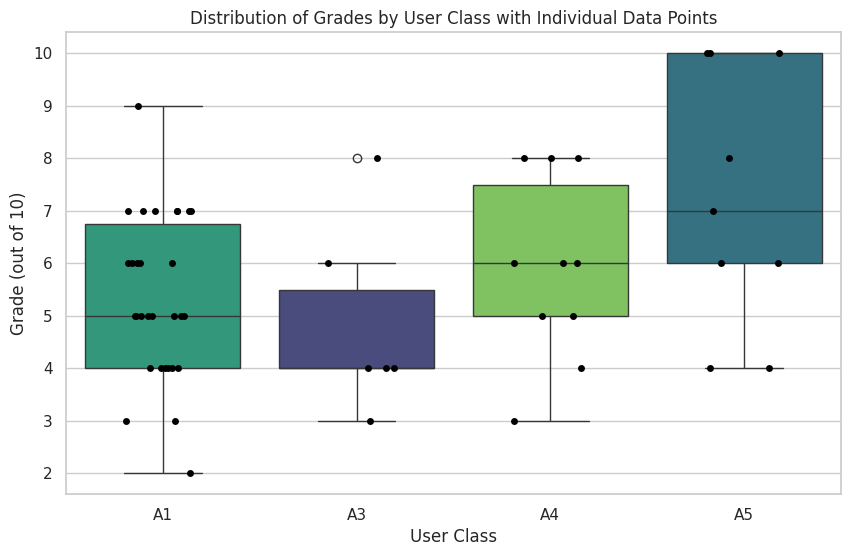

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='user_name_x', y='grade', data=participant_df, palette='viridis', hue='user_name_x', legend=False, order=['A1', 'A3', 'A4', 'A5'])
sns.stripplot(x='user_name_x', y='grade', data=participant_df, color='black', jitter=0.2, size=5, order=['A1', 'A3', 'A4', 'A5'])
plt.title('Distribution of Grades by User Class with Individual Data Points')
plt.xlabel('User Class')
plt.ylabel('Grade (out of 10)')
plt.show()

### Distribution of Grades (Accuracy)

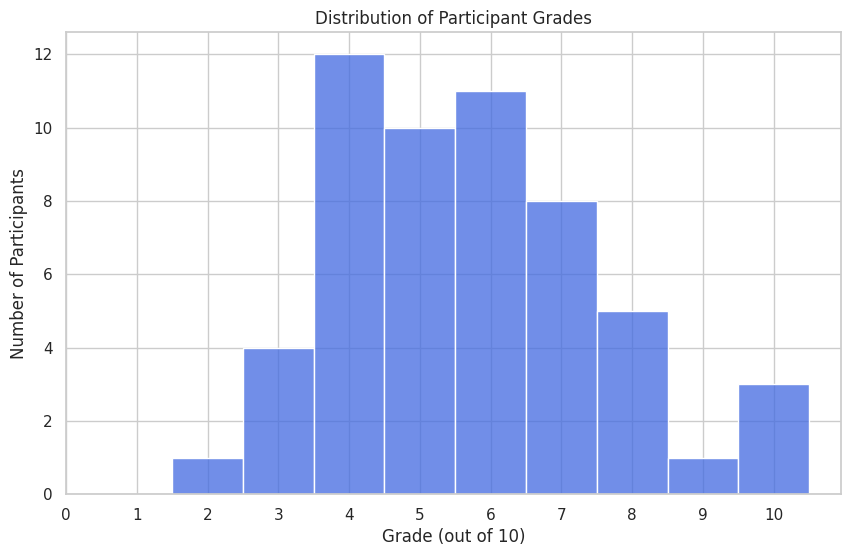

In [ ]:
plt.figure(figsize=(10, 6))
bins = np.arange(-0.5, 10.5 + 1, 1) # Bin edges for grades 0-10, centered
sns.histplot(participant_df['grade'], bins=bins, kde=False, discrete=True, color='royalblue')
plt.xticks(np.arange(0, 11, 1)) # Labels at 0, 1, ..., 10
plt.title('Distribution of Participant Grades')
plt.xlabel('Grade (out of 10)')
plt.ylabel('Number of Participants')
plt.show()

### Normality Test (Shapiro-Wilk) for Overall Grade Distribution

In [ ]:
# Perform Shapiro-Wilk test on the entire 'grade' column
shapiro_overall_stat, shapiro_overall_p = stats.shapiro(participant_df['grade'])
print(f"\nShapiro-Wilk Test for Overall Grades:\n  Statistic = {shapiro_overall_stat:.3f}, p-value = {shapiro_overall_p:.3f}")

# Interpret the result using the predefined alpha level
if shapiro_overall_p > alpha:
    print(f"  -> Fail to reject H0: Overall grades appear normally distributed (p > {alpha})")
else:
    print(f"  -> Reject H0: Overall grades do not appear normally distributed (p <= {alpha})")

print('\nInterpretation:')
print('A significant p-value (p <= alpha) suggests that the data deviates from a normal distribution.')
print('This test helps to understand if the assumption of normality holds for the entire dataset before further analysis or group comparisons.')


Shapiro-Wilk Test for Overall Grades:
  Statistic = 0.950, p-value = 0.023
  -> Reject H0: Overall grades do not appear normally distributed (p <= 0.05)

Interpretation:
A significant p-value (p <= alpha) suggests that the data deviates from a normal distribution.
This test helps to understand if the assumption of normality holds for the entire dataset before further analysis or group comparisons.


### Distibution og Grades & Number of Use AI

A boxplot is suitable here to show the distribution of grades for each distinct value of `n_used_ia`. Exploratory relationship between AI usage frequency and quiz grade.

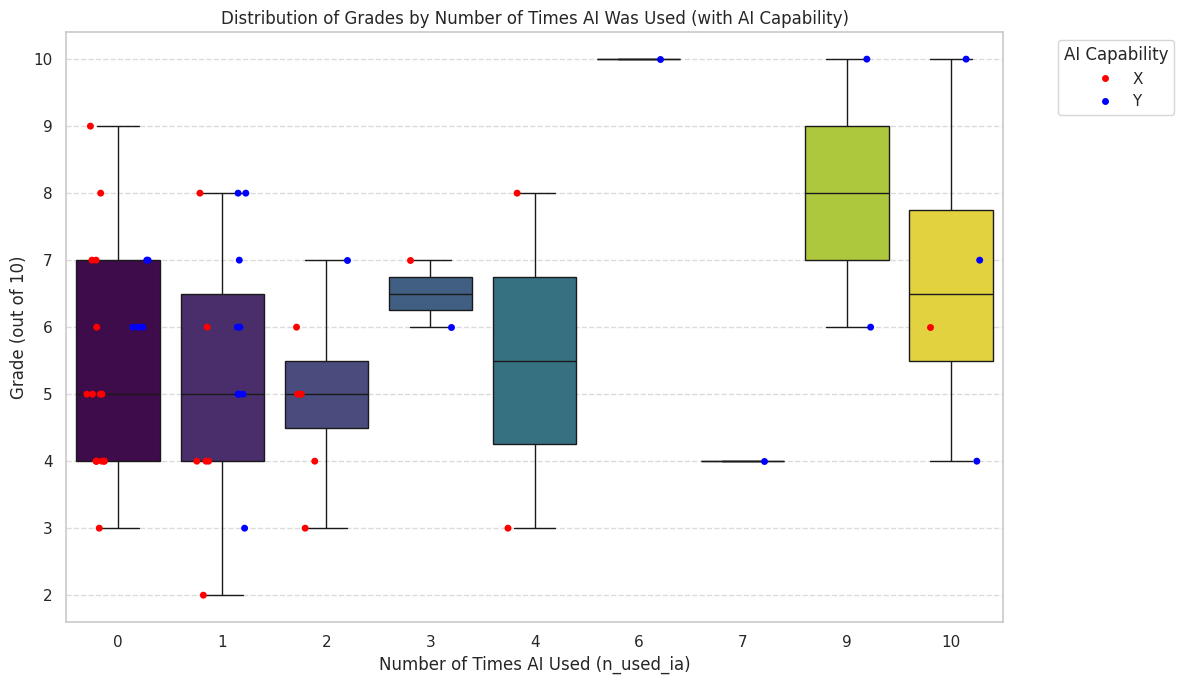

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='n_used_ia', y='grade', data=participant_df, palette='viridis', hue='n_used_ia', legend=False)
sns.stripplot(x='n_used_ia', y='grade', data=participant_df, hue='group_XY', palette={'X': 'red', 'Y': 'blue'}, jitter=0.2, size=5, dodge=True)
plt.title('Distribution of Grades by Number of Times AI Was Used (with AI Capability)')
plt.xlabel('Number of Times AI Used (n_used_ia)')
plt.ylabel('Grade (out of 10)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='AI Capability', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 6. Hypothesis Testing

### Quiz Performance


---



**Effect of AI Capability on Quiz Grade**

#### Research premise
This hypothesis investigates whether the capability of the AI system (weakened vs. standard) has an impact on participants' grades. Specifically, we expect participants who interact with a weakened AI system (Group X) to achieve lower grades compared to those who interact with a standard AI system (Group Y).

#### Variable and level of analysis
- Dependent variable: `grade` (overall score from 0-10 on the quiz)
- Unit of analysis: `participant` (each row in `participant_df` represents a unique participant)
- Groups compared: Group X (participants using weakened AI) vs. Group Y (participants using standard AI)

#### Null and alternative hypotheses
- $H_0$: There is no difference in the median `grade` between participants in Group X (weakened AI) and Group Y (standard AI). (Median Grade X $\ge$ Median Grade Y)
- $H_a$: The median `grade` of participants in Group X (weakened AI) is less than the median `grade` of participants in Group Y (standard AI). (Median Grade X $<$ Median Grade Y)

#### Choice of test
Given that the overall `grade` distribution was found to be non-normal (as indicated by the Shapiro-Wilk test earlier), and anticipating that the grades within Group X and Group Y might also deviate from normality, a non-parametric test is appropriate. The **Mann-Whitney U test** (also known as the Wilcoxon rank-sum test) is chosen as it compares the medians of two independent groups without assuming normal distribution of the data. Since the alternative hypothesis is directional (Grade X < Grade Y), a one-sided test with `alternative='less'` will be used.

#### Prepare data


In [ ]:
group_X_grades = participant_df[participant_df['group_XY'] == 'X']['grade']
group_Y_grades = participant_df[participant_df['group_XY'] == 'Y']['grade']

print(f"Number of participants in Group X (weakened AI): {len(group_X_grades)}")
print(f"Number of participants in Group Y (standard AI): {len(group_Y_grades)}")


Number of participants in Group X (weakened AI): 32
Number of participants in Group Y (standard AI): 23


#### Descriptive statistics

In [ ]:
print("Descriptive Statistics for Group X (weakened AI grades):\n", group_X_grades.describe())
print("\nDescriptive Statistics for Group Y (standard AI grades):\n", group_Y_grades.describe())


Descriptive Statistics for Group X (weakened AI grades):
 count    32.000000
mean      5.125000
std       1.699146
min       2.000000
25%       4.000000
50%       5.000000
75%       6.000000
max       9.000000
Name: grade, dtype: float64

Descriptive Statistics for Group Y (standard AI grades):
 count    23.000000
mean      6.478261
std       1.855448
min       3.000000
25%       5.500000
50%       6.000000
75%       7.000000
max      10.000000
Name: grade, dtype: float64


#### Data visualization

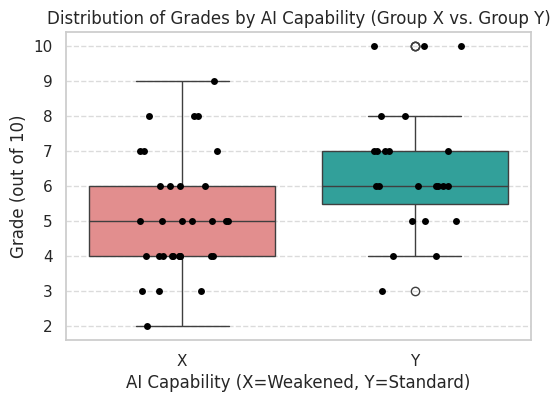

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='group_XY', y='grade', data=participant_df, palette={'X': 'lightcoral', 'Y': 'lightseagreen'}, hue='group_XY', legend=False)
sns.stripplot(x='group_XY', y='grade', data=participant_df, color='black', jitter=0.2, size=5)
plt.title('Distribution of Grades by AI Capability (Group X vs. Group Y)')
plt.xlabel('AI Capability (X=Weakened, Y=Standard)')
plt.ylabel('Grade (out of 10)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#### Statistical test

In [ ]:
# Perform one-sided Mann-Whitney U test (alternative='less' as per H_a)
# This tests if the distribution underlying x is stochastically less than the distribution underlying y.
# In our case, x = group_X_grades, y = group_Y_grades
statistic, p_value = mannwhitneyu(group_X_grades, group_Y_grades, alternative='less')

print(f"Mann-Whitney U Test (Group X vs. Group Y grades):")
print(f"  Statistic = {statistic:.3f}")
print(f"  P-value = {p_value:.3f}")

# Interpret the result
if p_value < alpha:
    print(f"  -> Reject H0: The median grade of Group X is significantly less than Group Y (p < {alpha})")
else:
    print(f"  -> Fail to reject H0: There is no significant evidence that the median grade of Group X is less than Group Y (p >= {alpha})")

print('\nInterpretation notes:')
print("The Mann-Whitney U test assesses if one sample tends to have larger values than the other. A significant p-value (p < alpha) supports the alternative hypothesis that grades in Group X are stochastically smaller than in Group Y.")


Mann-Whitney U Test (Group X vs. Group Y grades):
  Statistic = 214.500
  P-value = 0.004
  -> Reject H0: The median grade of Group X is significantly less than Group Y (p < 0.05)

Interpretation notes:
The Mann-Whitney U test assesses if one sample tends to have larger values than the other. A significant p-value (p < alpha) supports the alternative hypothesis that grades in Group X are stochastically smaller than in Group Y.


**Effect of Reliability Framing on Quiz Grade**

#### Research premise
This hypothesis examines whether a participant's reliability framing of AI (Group A) or lack thereof (Group B) influences their final grade. We hypothesize that participants who received reliability framing of the AI's presence might exhibit different performance outcomes compared to those who were not.

#### Variable and level of analysis
- Dependent variable: `grade` (overall score from 0-10 on the quiz)
- Unit of analysis: `participant` (each row in `participant_df` represents a unique participant)
- Groups compared: Group A (aware participants) vs. Group B (unaware participants)

#### Null and alternative hypotheses
- $H_0$: There is no difference in the median `grade` between participants in Group A (aware) and Group B (unaware). (Median Grade A = Median Grade B)
- $H_a$: There is a difference in the median `grade` between participants in Group A (aware) and Group B (unaware). (Median Grade A $
e$ Median Grade B)

#### Choice of test
Given that the overall `grade` distribution was found to be non-normal, and considering the potential non-normality of grades within Group A and Group B, a non-parametric test is appropriate. The **Mann-Whitney U test** is chosen to compare the medians of two independent groups without assuming a normal distribution. Since the alternative hypothesis is non-directional (Median Grade A $\ne$ Median Grade B), a two-sided test with `alternative='two-sided'` will be used.

#### Prepare data


In [ ]:
group_A_grades = participant_df[participant_df['group_AB'] == 'A']['grade']
group_B_grades = participant_df[participant_df['group_AB'] == 'B']['grade']

print(f"Number of participants in Group A (aware): {len(group_A_grades)}")
print(f"Number of participants in Group B (unaware): {len(group_B_grades)}")


Number of participants in Group A (aware): 23
Number of participants in Group B (unaware): 32


#### Descriptive statistics

In [ ]:
print("Descriptive Statistics for Group A (aware grades):\n", group_A_grades.describe())
print("\nDescriptive Statistics for Group B (unaware grades):\n", group_B_grades.describe())


Descriptive Statistics for Group A (aware grades):
 count    23.000000
mean      5.652174
std       1.799209
min       3.000000
25%       4.000000
50%       6.000000
75%       7.000000
max      10.000000
Name: grade, dtype: float64

Descriptive Statistics for Group B (unaware grades):
 count    32.000000
mean      5.718750
std       1.954884
min       2.000000
25%       4.750000
50%       5.500000
75%       7.000000
max      10.000000
Name: grade, dtype: float64


#### Data visualization

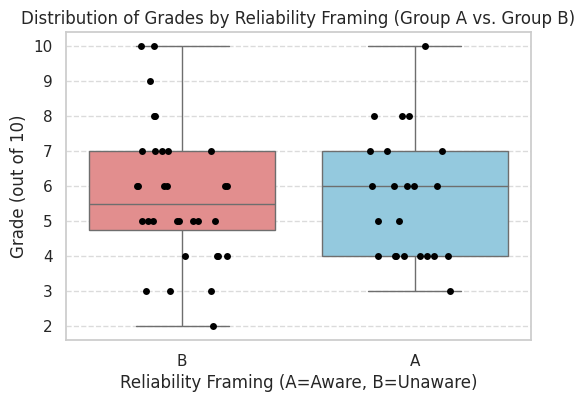

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='group_AB', y='grade', data=participant_df, palette={'A': 'skyblue', 'B': 'lightcoral'}, hue='group_AB', legend=False)
sns.stripplot(x='group_AB', y='grade', data=participant_df, color='black', jitter=0.2, size=5)
plt.title('Distribution of Grades by Reliability Framing (Group A vs. Group B)')
plt.xlabel('Reliability Framing (A=Aware, B=Unaware)')
plt.ylabel('Grade (out of 10)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Statistical test

In [ ]:
# Perform two-sided Mann-Whitney U test (alternative='two-sided' as per H_a)
statistic, p_value = mannwhitneyu(group_A_grades, group_B_grades, alternative='two-sided')

print(f"Mann-Whitney U Test (Group A vs. Group B grades):")
print(f"  Statistic = {statistic:.3f}")
print(f"  P-value = {p_value:.3f}")

# Interpret the result
if p_value < alpha:
    print(f"  -> Reject H0: There is a statistically significant difference in median grades between Group A and Group B (p < {alpha})")
else:
    print(f"  -> Fail to reject H0: There is no statistically significant difference in median grades between Group A and Group B (p >= {alpha})")

print('\nInterpretation notes:')
print("The Mann-Whitney U test assesses if the distributions of two independent samples are different. A significant p-value (p < alpha) supports the alternative hypothesis that there is a difference in the median grades.")


Mann-Whitney U Test (Group A vs. Group B grades):
  Statistic = 358.000
  P-value = 0.869
  -> Fail to reject H0: There is no statistically significant difference in median grades between Group A and Group B (p >= 0.05)

Interpretation notes:
The Mann-Whitney U test assesses if the distributions of two independent samples are different. A significant p-value (p < alpha) supports the alternative hypothesis that there is a difference in the median grades.


**Differences in Quiz Grade Across the Four Experimental Groups**

#### Research premise
This hypothesis investigates the combined effect of AI capability (weakened/standard) and reliability framing (aware/unaware) on participant grades across the four original experimental groups (G1, G2, G3, G4). We aim to determine if different combinations of AI capability and reliability framing lead to significant differences in participant performance, as measured by their grades.

#### Variable and level of analysis
- Dependent variable: `grade` (overall score from 0-10 on the quiz)
- Unit of analysis: `participant` (each row in `participant_df` represents a unique participant)
- Groups compared: G1 (aware + weakened), G2 (aware + standard), G3 (unaware + weakened), G4 (unaware + standard)

#### Null and alternative hypotheses
- $H_0$: There is no difference in the median `grade` among the four experimental groups (G1, G2, G3, G4).
- $H_a$: At least one group's median `grade` is different from another group's median `grade`.

#### Choice of test
Given that the overall `grade` distribution is non-normal and we are comparing the medians of more than two independent groups, a non-parametric test is appropriate. The **Kruskal-Wallis H test** will be used to determine if there are statistically significant differences between the medians of the four groups (G1, G2, G3, G4).

#### Prepare data

In [ ]:
group_G1_grades = participant_df[participant_df['group_label'] == 'G1']['grade']
group_G2_grades = participant_df[participant_df['group_label'] == 'G2']['grade']
group_G3_grades = participant_df[participant_df['group_label'] == 'G3']['grade']
group_G4_grades = participant_df[participant_df['group_label'] == 'G4']['grade']

print(f"Number of participants in G1 (aware + weakened): {len(group_G1_grades)}")
print(f"Number of participants in G2 (aware + standard): {len(group_G2_grades)}")
print(f"Number of participants in G3 (unaware + weakened): {len(group_G3_grades)}")
print(f"Number of participants in G4 (unaware + standard): {len(group_G4_grades)}")


Number of participants in G1 (aware + weakened): 14
Number of participants in G2 (aware + standard): 9
Number of participants in G3 (unaware + weakened): 18
Number of participants in G4 (unaware + standard): 14


#### Descriptive statistics

In [ ]:
print("Descriptive Statistics for G1 grades (aware + weakened):\n", group_G1_grades.describe())
print("\nDescriptive Statistics for G2 grades (aware + standard):\n", group_G2_grades.describe())
print("\nDescriptive Statistics for G3 grades (unaware + weakened):\n", group_G3_grades.describe())
print("\nDescriptive Statistics for G4 grades (unaware + standard):\n", group_G4_grades.describe())


Descriptive Statistics for G1 grades (aware + weakened):
 count    14.000000
mean      5.214286
std       1.528125
min       4.000000
25%       4.000000
50%       4.500000
75%       6.000000
max       8.000000
Name: grade, dtype: float64

Descriptive Statistics for G2 grades (aware + standard):
 count     9.000000
mean      6.333333
std       2.061553
min       3.000000
25%       6.000000
50%       6.000000
75%       7.000000
max      10.000000
Name: grade, dtype: float64

Descriptive Statistics for G3 grades (unaware + weakened):
 count    18.000000
mean      5.055556
std       1.862074
min       2.000000
25%       4.000000
50%       5.000000
75%       6.000000
max       9.000000
Name: grade, dtype: float64

Descriptive Statistics for G4 grades (unaware + standard):
 count    14.000000
mean      6.571429
std       1.785165
min       4.000000
25%       5.250000
50%       6.000000
75%       7.000000
max      10.000000
Name: grade, dtype: float64


#### Data visualization

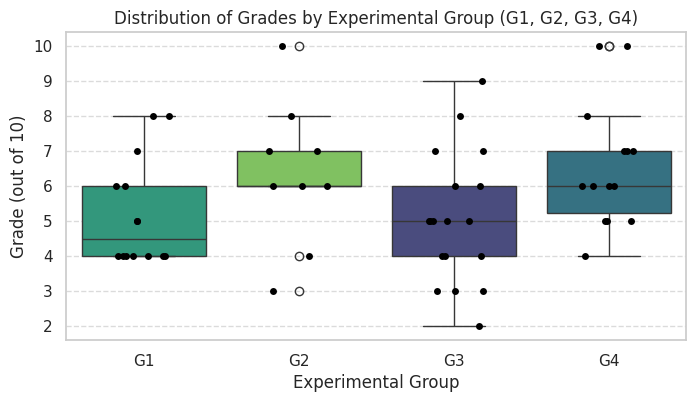

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='group_label', y='grade', data=participant_df, palette='viridis', hue='group_label', legend=False, order=['G1', 'G2', 'G3', 'G4'])
sns.stripplot(x='group_label', y='grade', data=participant_df, color='black', jitter=0.2, size=5, order=['G1', 'G2', 'G3', 'G4'])
plt.title('Distribution of Grades by Experimental Group (G1, G2, G3, G4)')
plt.xlabel('Experimental Group')
plt.ylabel('Grade (out of 10)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#### Statistical test

In [ ]:
# Perform Kruskal-Wallis H test
kruskal_stat, kruskal_p = stats.kruskal(group_G1_grades, group_G2_grades, group_G3_grades, group_G4_grades)

print(f"Kruskal-Wallis H Test for H2 (G1, G2, G3, G4 grades):")
print(f"  Statistic = {kruskal_stat:.3f}")
print(f"  P-value = {kruskal_p:.3f}")

# Interpret Kruskal-Wallis result
if kruskal_p < alpha:
    print(f"  -> Reject H0: There is a statistically significant difference in median grades among the groups (p < {alpha})")
    print("\nPerforming Dunn's post-hoc test to find specific differences:")
    # Prepare data for post-hoc test in a single DataFrame
    data_for_posthoc = pd.DataFrame({
        'grade': pd.concat([group_G1_grades, group_G2_grades, group_G3_grades, group_G4_grades]),
        'group': ['G1']*len(group_G1_grades) + ['G2']*len(group_G2_grades) + \
                 ['G3']*len(group_G3_grades) + ['G4']*len(group_G4_grades)
    })

    dunn_results = posthoc_dunn(data_for_posthoc, val_col='grade', group_col='group', p_adjust='bonferroni')
    print(dunn_results)
else:
    print(f"  -> Fail to reject H0: No statistically significant difference in median grades among the groups (p >= {alpha})")

print('\nInterpretation notes:')
print("The Kruskal-Wallis H test determines if population medians are equal. If significant, Dunn's post-hoc test (with Bonferroni correction) identifies which pairs of groups differ significantly.")


Kruskal-Wallis H Test for H2 (G1, G2, G3, G4 grades):
  Statistic = 7.161
  P-value = 0.067
  -> Fail to reject H0: No statistically significant difference in median grades among the groups (p >= 0.05)

Interpretation notes:
The Kruskal-Wallis H test determines if population medians are equal. If significant, Dunn's post-hoc test (with Bonferroni correction) identifies which pairs of groups differ significantly.


### AI Usage Frequency



---



**Effect of AI Capability on AI Usage Frequency**

#### Research premise
This hypothesis investigates whether the AI's capability (weakened vs. standard) influences the frequency of AI usage by participants. We expect participants in the weakened AI group (Group X) to use AI less frequently than those in the standard AI group (Group Y).

#### Variable and level of analysis
- Dependent variable: `n_used_ia` (number of times AI was used)
- Unit of analysis: `participant` (each row in `participant_df` represents a unique participant)
- Groups compared: Group X (participants using weakened AI) vs. Group Y (participants using standard AI)

#### Null and alternative hypotheses
- $H_0$: There is no difference in the median frequency of AI usage (`n_used_ia`) between participants in Group X (weakened AI) and Group Y (standard AI). (Median $n_{used\_ia, X} \ge$ Median $n_{used\_ia, Y}$)
- $H_a$: The median frequency of AI usage (`n_used_ia`) of participants in Group X (weakened AI) is less than the median frequency of AI usage of participants in Group Y (standard AI). (Median $n_{used\_ia, X} <$ Median $n_{used\_ia, Y}$)

#### Choice of test
Given that `n_used_ia` is a count variable and likely non-normally distributed, a non-parametric test is appropriate. The **Mann-Whitney U test** will be used to compare the medians of `n_used_ia` between Group X and Group Y. Since the alternative hypothesis is directional (Group X < Group Y), a one-sided test with `alternative='less'` will be used. Additionally, **Levene's test** will be employed to assess the homogeneity of variances, as it is robust to non-normal data and useful for detecting differences in spread between groups.

#### Prepare data

In [ ]:
group_X_n_used_ia = participant_df[participant_df['group_XY'] == 'X']['n_used_ia']
group_Y_n_used_ia = participant_df[participant_df['group_XY'] == 'Y']['n_used_ia']

print(f"Number of participants in Group X (weakened AI): {len(group_X_n_used_ia)}")
print(f"Number of participants in Group Y (standard AI): {len(group_Y_n_used_ia)}")

Number of participants in Group X (weakened AI): 32
Number of participants in Group Y (standard AI): 23


#### Descriptive statistics

In [ ]:
print("Descriptive Statistics for Group X (weakened AI, n_used_ia):\n", group_X_n_used_ia.describe())
print("Median Group X:", group_X_n_used_ia.median())

print("\nDescriptive Statistics for Group Y (standard AI, n_used_ia):\n", group_Y_n_used_ia.describe())
print("Median Group Y:", group_Y_n_used_ia.median())

Descriptive Statistics for Group X (weakened AI, n_used_ia):
 count    32.000000
mean      1.218750
std       1.995711
min       0.000000
25%       0.000000
50%       0.500000
75%       2.000000
max      10.000000
Name: n_used_ia, dtype: float64
Median Group X: 0.5

Descriptive Statistics for Group Y (standard AI, n_used_ia):
 count    23.000000
mean      3.260870
std       3.840187
min       0.000000
25%       1.000000
50%       1.000000
75%       6.500000
max      10.000000
Name: n_used_ia, dtype: float64
Median Group Y: 1.0


#### Data visualization

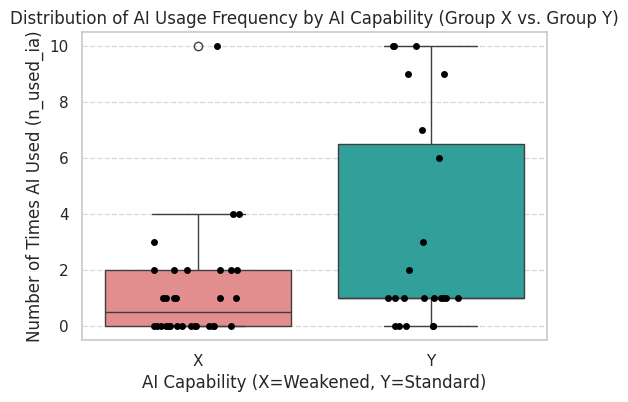

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='group_XY', y='n_used_ia', data=participant_df, palette={'X': 'lightcoral', 'Y': 'lightseagreen'}, hue='group_XY', legend=False)
sns.stripplot(x='group_XY', y='n_used_ia', data=participant_df, color='black', jitter=0.2, size=5)
plt.title('Distribution of AI Usage Frequency by AI Capability (Group X vs. Group Y)')
plt.xlabel('AI Capability (X=Weakened, Y=Standard)')
plt.ylabel('Number of Times AI Used (n_used_ia)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Statistical test

In [ ]:
# Mann-Whitney U test (one-sided: alternative='less' as per H_a)
# This tests if the distribution underlying x is stochastically less than the distribution underlying y.
# In our case, x = group_X_n_used_ia, y = group_Y_n_used_ia
mw_statistic, mw_p_value = mannwhitneyu(group_X_n_used_ia, group_Y_n_used_ia, alternative='less')

print(f"Mann-Whitney U Test (Group X vs. Group Y n_used_ia, one-sided):")
print(f"  Statistic = {mw_statistic:.3f}")
print(f"  P-value = {mw_p_value:.3f}")

# Interpret the Mann-Whitney U result
if mw_p_value < alpha:
    print(f"  -> Reject H0: The median n_used_ia of Group X is significantly less than Group Y (p < {alpha})")
else:
    print(f"  -> Fail to reject H0: There is no significant evidence that the median n_used_ia of Group X is less than Group Y (p >= {alpha})")

print('\nInterpretation notes for Mann-Whitney U:')
print("The Mann-Whitney U test assesses if one sample tends to have larger values than the other. A significant p-value (p < alpha) supports the alternative hypothesis that AI usage in Group X is stochastically smaller than in Group Y.")

# Levene's test for homogeneity of variances
levene_statistic, levene_p_value = levene(group_X_n_used_ia, group_Y_n_used_ia)

print(f"\nLevene's Test (Homogeneity of Variances for n_used_ia):")
print(f"  Statistic = {levene_statistic:.3f}")
print(f"  P-value = {levene_p_value:.3f}")

# Interpret Levene's test result
if levene_p_value < alpha:
    print(f"  -> Reject H0: Variances are significantly different between Group X and Group Y (p < {alpha})")
else:
    print(f"  -> Fail to reject H0: Variances are not significantly different between Group X and Group Y (p >= {alpha})")

print('\nInterpretation notes for Levene\'s Test:')
print("Levene's test checks if the population variances are equal across groups. A significant p-value (p < alpha) suggests that the assumption of homogeneity of variances is violated.")

Mann-Whitney U Test (Group X vs. Group Y n_used_ia, one-sided):
  Statistic = 253.000
  P-value = 0.021
  -> Reject H0: The median n_used_ia of Group X is significantly less than Group Y (p < 0.05)

Interpretation notes for Mann-Whitney U:
The Mann-Whitney U test assesses if one sample tends to have larger values than the other. A significant p-value (p < alpha) supports the alternative hypothesis that AI usage in Group X is stochastically smaller than in Group Y.

Levene's Test (Homogeneity of Variances for n_used_ia):
  Statistic = 4.211
  P-value = 0.045
  -> Reject H0: Variances are significantly different between Group X and Group Y (p < 0.05)

Interpretation notes for Levene's Test:
Levene's test checks if the population variances are equal across groups. A significant p-value (p < alpha) suggests that the assumption of homogeneity of variances is violated.


**Effect of Reliability Framing on AI Usage Frequency**

#### Research premise
This hypothesis investigates whether a participant's reliability framing of AI (Group A) or lack thereof (Group B) influences the frequency of AI usage. We hypothesize that participants who received reliability framing of the AI system (Group A) might use AI differently compared to participants who did not receive reliability framing(Group B).

#### Variable and level of analysis
- Dependent variable: `n_used_ia` (count of AI usage)
- Unit of analysis: `participant` (each row in `participant_df` represents a unique participant)
- Groups compared: Group A (aware participants) vs. Group B (unaware participants)

#### Null and alternative hypotheses
- $H_0$: There is no difference in the median frequency of AI usage (`n_used_ia`) between participants in Group A (aware) and Group B (unaware). (Median $n_{used\_ia, A}$ = Median $n_{used\_ia, B}$)
- $H_a$: There is a difference in the median frequency of AI usage (`n_used_ia`) between participants in Group A (aware) and Group B (unaware). (Median $n_{used\_ia, A} \ne$ Median $n_{used\_ia, B}$)

#### Choice of test
Given that the `n_used_ia` variable is a count and likely non-normally distributed, a non-parametric test is appropriate. The **Mann-Whitney U test (two-sided)** will be used to compare the medians of `n_used_ia` between Group A and Group B. Additionally, the **Levene's test** will be used to assess the homogeneity of variances, as it is robust to non-normal data and useful for detecting differences in spread between groups.

#### Prepare data

In [ ]:
group_A_n_used_ia = participant_df[participant_df['group_AB'] == 'A']['n_used_ia']
group_B_n_used_ia = participant_df[participant_df['group_AB'] == 'B']['n_used_ia']

print(f"Number of participants in Group A (aware): {len(group_A_n_used_ia)}")
print(f"Number of participants in Group B (unaware): {len(group_B_n_used_ia)}")

Number of participants in Group A (aware): 23
Number of participants in Group B (unaware): 32


#### Descriptive statistics

In [ ]:
print("Descriptive Statistics for Group A (aware, n_used_ia):")
print(group_A_n_used_ia.describe())
print(f"Median Group A: {group_A_n_used_ia.median()}")

print("\nDescriptive Statistics for Group B (unaware, n_used_ia):")
print(group_B_n_used_ia.describe())
print(f"Median Group B: {group_B_n_used_ia.median()}")

Descriptive Statistics for Group A (aware, n_used_ia):
count    23.000000
mean      1.347826
std       2.308260
min       0.000000
25%       0.000000
50%       1.000000
75%       1.500000
max      10.000000
Name: n_used_ia, dtype: float64
Median Group A: 1.0

Descriptive Statistics for Group B (unaware, n_used_ia):
count    32.000000
mean      2.593750
std       3.434731
min       0.000000
25%       0.000000
50%       1.000000
75%       3.250000
max      10.000000
Name: n_used_ia, dtype: float64
Median Group B: 1.0


#### Data visualization

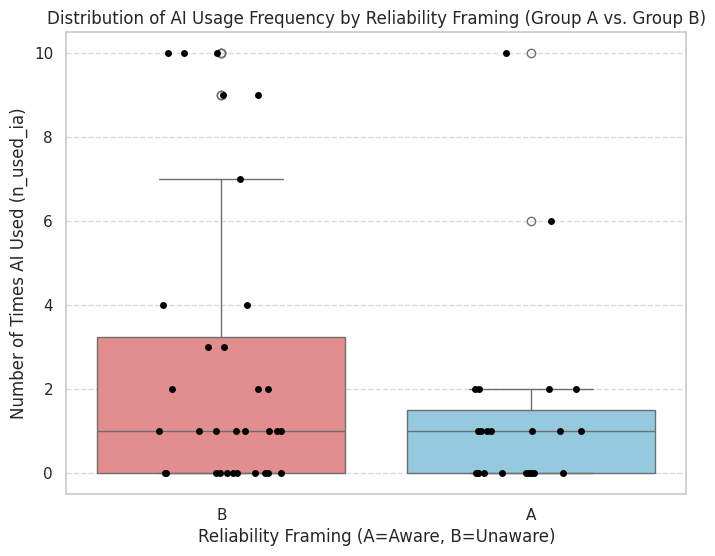

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='group_AB', y='n_used_ia', data=participant_df, palette={'A': 'skyblue', 'B': 'lightcoral'}, hue='group_AB', legend=False)
sns.stripplot(x='group_AB', y='n_used_ia', data=participant_df, color='black', jitter=0.2, size=5)
plt.title('Distribution of AI Usage Frequency by Reliability Framing (Group A vs. Group B)')
plt.xlabel('Reliability Framing (A=Aware, B=Unaware)')
plt.ylabel('Number of Times AI Used (n_used_ia)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Statistical test

In [ ]:
# Mann-Whitney U test (two-sided as per H_a)
mw_statistic_h7, mw_p_value_h7 = mannwhitneyu(group_A_n_used_ia, group_B_n_used_ia, alternative='two-sided')

print(f"Mann-Whitney U Test (Group A vs. Group B n_used_ia):")
print(f"  Statistic = {mw_statistic_h7:.3f}")
print(f"  P-value = {mw_p_value_h7:.3f}")

# Interpret the Mann-Whitney U result
if mw_p_value_h7 < alpha:
    print(f"  -> Reject H0: There is a statistically significant difference in median n_used_ia between Group A and Group B (p < {alpha})")
else:
    print(f"  -> Fail to reject H0: No statistically significant difference in median n_used_ia between Group A and Group B (p >= {alpha})")

print('\nInterpretation notes for Mann-Whitney U:')
print("The Mann-Whitney U test assesses if the distributions of two independent samples are different. A significant p-value (p < alpha) supports the alternative hypothesis that there is a difference in the median frequency of AI usage.")

# Levene's test for homogeneity of variances
levene_statistic_h7, levene_p_value_h7 = levene(group_A_n_used_ia, group_B_n_used_ia)

print(f"\nLevene's Test (Homogeneity of Variances for n_used_ia):")
print(f"  Statistic = {levene_statistic_h7:.3f}")
print(f"  P-value = {levene_p_value_h7:.3f}")

# Interpret Levene's test result
if levene_p_value_h7 < alpha:
    print(f"  -> Reject H0: Variances are significantly different between Group A and Group B (p < {alpha})")
else:
    print(f"  -> Fail to reject H0: Variances are not significantly different between Group A and Group B (p >= {alpha})")

print('\nInterpretation notes for Levene\'s Test:')
print("Levene's test checks if the population variances are equal across groups. A significant p-value (p < alpha) suggests that the assumption of homogeneity of variances is violated.")

Mann-Whitney U Test (Group A vs. Group B n_used_ia):
  Statistic = 298.500
  P-value = 0.220
  -> Fail to reject H0: No statistically significant difference in median n_used_ia between Group A and Group B (p >= 0.05)

Interpretation notes for Mann-Whitney U:
The Mann-Whitney U test assesses if the distributions of two independent samples are different. A significant p-value (p < alpha) supports the alternative hypothesis that there is a difference in the median frequency of AI usage.

Levene's Test (Homogeneity of Variances for n_used_ia):
  Statistic = 2.191
  P-value = 0.145
  -> Fail to reject H0: Variances are not significantly different between Group A and Group B (p >= 0.05)

Interpretation notes for Levene's Test:
Levene's test checks if the population variances are equal across groups. A significant p-value (p < alpha) suggests that the assumption of homogeneity of variances is violated.


**Differences in AI Usage Frequency Across the Four Experimental Groups**

#### Research premise
This hypothesis investigates the combined effect of AI capability (weakened/standard) and reliability framing (aware/unaware) on the frequency of AI usage across the four original experimental groups (G1, G2, G3, G4). We aim to determine if different combinations of AI capability and reliability framing lead to significant differences in how often participants use the AI.

#### Variable and level of analysis
- Dependent variable: `n_used_ia` (count of AI usage)
- Unit of analysis: `participant` (each row in `participant_df` represents a unique participant)
- Groups compared: G1 (aware + weakened), G2 (aware + standard), G3 (unaware + weakened), G4 (unaware + standard)

#### Null and alternative hypotheses
- $H_0$: There is no difference in the median frequency of AI usage (`n_used_ia`) among the four experimental groups (G1, G2, G3, G4).
- $H_a$: At least one group's median frequency of AI usage (`n_used_ia`) is different from another group's median frequency.

#### Choice of test
Given that `n_used_ia` is a count and likely non-normally distributed, and we are comparing the medians of more than two independent groups, a non-parametric test is appropriate. The **Kruskal-Wallis H test** will be used to determine if there are statistically significant differences between the medians of the four groups (G1, G2, G3, G4). Additionally, **Levene's test** will be used to assess the homogeneity of variances.

If the Kruskal-Wallis test yields a significant result ($p < \alpha$), a **Dunn's post-hoc test with Bonferroni correction** will be performed to identify which specific pairs of groups have significantly different medians, while controlling for the family-wise error rate.

#### Prepare data

In [ ]:
group_G1_n_used_ia = participant_df[participant_df['group_label'] == 'G1']['n_used_ia']
group_G2_n_used_ia = participant_df[participant_df['group_label'] == 'G2']['n_used_ia']
group_G3_n_used_ia = participant_df[participant_df['group_label'] == 'G3']['n_used_ia']
group_G4_n_used_ia = participant_df[participant_df['group_label'] == 'G4']['n_used_ia']

print(f"Number of participants in G1 (aware + weakened): {len(group_G1_n_used_ia)}")
print(f"Number of participants in G2 (aware + standard): {len(group_G2_n_used_ia)}")
print(f"Number of participants in G3 (unaware + weakened): {len(group_G3_n_used_ia)}")
print(f"Number of participants in G4 (unaware + standard): {len(group_G4_n_used_ia)}")

Number of participants in G1 (aware + weakened): 14
Number of participants in G2 (aware + standard): 9
Number of participants in G3 (unaware + weakened): 18
Number of participants in G4 (unaware + standard): 14


#### Descriptive statistics

In [ ]:
print("Descriptive Statistics for G1 n_used_ia (aware + weakened):\n", group_G1_n_used_ia.describe())
print("Median Group G1: ", group_G1_n_used_ia.median())

print("\nDescriptive Statistics for G2 n_used_ia (aware + standard):\n", group_G2_n_used_ia.describe())
print("Median Group G2: ", group_G2_n_used_ia.median())

print("\nDescriptive Statistics for G3 n_used_ia (unaware + weakened):\n", group_G3_n_used_ia.describe())
print("Median Group G3: ", group_G3_n_used_ia.median())

print("\nDescriptive Statistics for G4 n_used_ia (unaware + standard):\n", group_G4_n_used_ia.describe())
print("Median Group G4: ", group_G4_n_used_ia.median())

Descriptive Statistics for G1 n_used_ia (aware + weakened):
 count    14.000000
mean      0.642857
std       0.841897
min       0.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       2.000000
Name: n_used_ia, dtype: float64
Median Group G1:  0.0

Descriptive Statistics for G2 n_used_ia (aware + standard):
 count     9.000000
mean      2.444444
std       3.358240
min       0.000000
25%       1.000000
50%       1.000000
75%       2.000000
max      10.000000
Name: n_used_ia, dtype: float64
Median Group G2:  1.0

Descriptive Statistics for G3 n_used_ia (unaware + weakened):
 count    18.000000
mean      1.666667
std       2.497057
min       0.000000
25%       0.000000
50%       1.000000
75%       2.000000
max      10.000000
Name: n_used_ia, dtype: float64
Median Group G3:  1.0

Descriptive Statistics for G4 n_used_ia (unaware + standard):
 count    14.000000
mean      3.785714
std       4.154304
min       0.000000
25%       1.000000
50%       1.000000
75%       8.50000

#### Data visualization

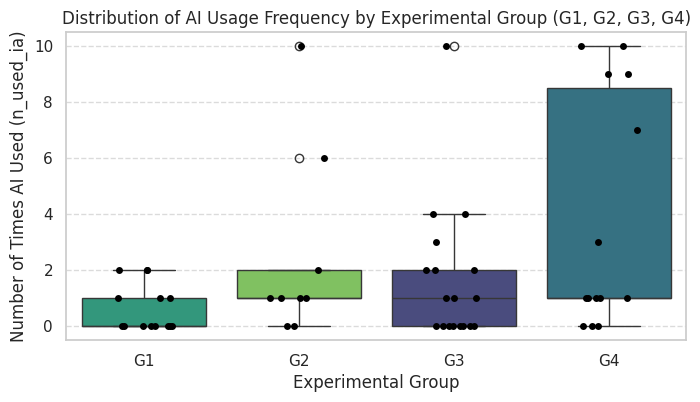

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='group_label', y='n_used_ia', data=participant_df, palette='viridis', hue='group_label', legend=False, order=['G1', 'G2', 'G3', 'G4'])
sns.stripplot(x='group_label', y='n_used_ia', data=participant_df, color='black', jitter=0.2, size=5, order=['G1', 'G2', 'G3', 'G4'])
plt.title('Distribution of AI Usage Frequency by Experimental Group (G1, G2, G3, G4)')
plt.xlabel('Experimental Group')
plt.ylabel('Number of Times AI Used (n_used_ia)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Statistical test

In [ ]:
# Perform Kruskal-Wallis H test
kruskal_stat_h8, kruskal_p_h8 = stats.kruskal(group_G1_n_used_ia, group_G2_n_used_ia, group_G3_n_used_ia, group_G4_n_used_ia)

print(f"Kruskal-Wallis H Test (G1, G2, G3, G4 n_used_ia):")
print(f"  Statistic = {kruskal_stat_h8:.3f}")
print(f"  P-value = {kruskal_p_h8:.3f}")

# Interpret Kruskal-Wallis result
if kruskal_p_h8 < alpha:
    print(f"  -> Reject H0: There is a statistically significant difference in median n_used_ia among the groups (p < {alpha})")
    print("\nPerforming Dunn's post-hoc test to find specific differences:")
    # Prepare data for post-hoc test in a single DataFrame
    data_for_posthoc = pd.DataFrame({
        'n_used_ia': pd.concat([group_G1_n_used_ia, group_G2_n_used_ia, group_G3_n_used_ia, group_G4_n_used_ia]),
        'group': ['G1']*len(group_G1_n_used_ia) + ['G2']*len(group_G2_n_used_ia) + \
                 ['G3']*len(group_G3_n_used_ia) + ['G4']*len(group_G4_n_used_ia)
    })

    dunn_results = posthoc_dunn(data_for_posthoc, val_col='n_used_ia', group_col='group', p_adjust='bonferroni')
    print(dunn_results)
else:
    print(f"  -> Fail to reject H0: No statistically significant difference in median n_used_ia among the groups (p >= {alpha})")

# Levene's test for homogeneity of variances
levene_statistic_h8, levene_p_value_h8 = levene(group_G1_n_used_ia, group_G2_n_used_ia, group_G3_n_used_ia, group_G4_n_used_ia)

print(f"\nLevene's Test for H8 (Homogeneity of Variances for n_used_ia):")
print(f"  Statistic = {levene_statistic_h8:.3f}")
print(f"  P-value = {levene_p_value_h8:.3f}")

# Interpret Levene's test result
if levene_p_value_h8 < alpha:
    print(f"  -> Reject H0: Variances are significantly different between groups (p < {alpha})")
else:
    print(f"  -> Fail to reject H0: Variances are not significantly different between groups (p >= {alpha})")

print('\nInterpretation notes:')
print("The Kruskal-Wallis H test determines if population medians are equal across multiple groups. If significant, Dunn's post-hoc test (with Bonferroni correction) identifies which pairs of groups differ significantly. Levene's test checks if the population variances are equal across groups.")

Kruskal-Wallis H Test (G1, G2, G3, G4 n_used_ia):
  Statistic = 5.584
  P-value = 0.134
  -> Fail to reject H0: No statistically significant difference in median n_used_ia among the groups (p >= 0.05)

Levene's Test for H8 (Homogeneity of Variances for n_used_ia):
  Statistic = 2.361
  P-value = 0.082
  -> Fail to reject H0: Variances are not significantly different between groups (p >= 0.05)

Interpretation notes:
The Kruskal-Wallis H test determines if population medians are equal across multiple groups. If significant, Dunn's post-hoc test (with Bonferroni correction) identifies which pairs of groups differ significantly. Levene's test checks if the population variances are equal across groups.


### Post-Quiz Perception


---



**Effect of AI Capability on Post-Quiz Likert Responses**

#### Research premise
This hypothesis investigates whether the AI's capability (weakened vs. standard) influences participant perceptions as measured by various Likert-scale items. We aim to determine if participants in the weakened AI group (Group X) report different perceptions (e.g., changes in initial answer, confidence, doubt, movement toward AI, or answering differently without AI) compared to those in the standard AI group (Group Y).

#### Variable and level of analysis
- Dependent variables: `change_initial_answer`, `increase_confidence`, `doubt_reasoning`, `move_toward_ai`, `answer_differently_without_ai` (each on a Likert scale from -2 to 2)
- Unit of analysis: `participant` (each row in `participant_df` represents a unique participant)
- Groups compared: Group X (participants using weakened AI) vs. Group Y (participants using standard AI)

#### Null and alternative hypotheses
For each Likert item: \{`change_initial_answer`, `increase_confidence`, `doubt_reasoning`, `move_toward_ai`, `answer_differently_without_ai`}

- $H_0$: There is no difference in the median perception score for $item$ between participants in Group X (weakened AI) and Group Y (standard AI). (Median $item_X$ = Median $item_Y$)
- $H_a$: There is a difference in the median perception score for $item$ between participants in Group X (weakened AI) and Group Y (standard AI). (Median $item_X \ne$ Median $item_Y$)

#### Choice of test
Given the ordinal nature of Likert scale data and the lack of assumption of normality for such data, non-parametric tests are appropriate. For each of the five Likert items, a **Mann-Whitney U test (two-sided)** will be conducted to compare the median scores between Group X and Group Y. Additionally, the **Fligner-Killeen test** will be used to assess the homogeneity of variances (or scale parameters) for each item between the two groups.

#### Prepare data

In [ ]:
# Filter participant_df into Group X and Group Y
participant_df_X = participant_df[participant_df['group_XY'] == 'X']
participant_df_Y = participant_df[participant_df['group_XY'] == 'Y']

# List of Likert scale items to analyze
likert_items = [
    'change_initial_answer',
    'increase_confidence',
    'doubt_reasoning',
    'move_toward_ai',
    'answer_differently_without_ai'
]

print(f"Number of participants in Group X (weakened AI): {len(participant_df_X)}")
print(f"Number of participants in Group Y (standard AI): {len(participant_df_Y)}")


Number of participants in Group X (weakened AI): 32
Number of participants in Group Y (standard AI): 23


#### Descriptive statistics

In [ ]:
print("\nDescriptive Statistics for Likert Items (Group X vs. Group Y):\n")
for item in likert_items:
    print(f"--- {item.replace('_', ' ').title()} ---")
    print("Group X (weakened AI):")
    print(participant_df_X[item].describe())
    print("Median Group X:", participant_df_X[item].median())
    print("\nGroup Y (standard AI):")
    print(participant_df_Y[item].describe())
    print("Median Group Y:", participant_df_Y[item].median())
    print("\n")



Descriptive Statistics for Likert Items (Group X vs. Group Y):

--- Change Initial Answer ---
Group X (weakened AI):
count    32.000000
mean      0.093750
std       0.995453
min      -2.000000
25%       0.000000
50%       0.000000
75%       0.250000
max       2.000000
Name: change_initial_answer, dtype: float64
Median Group X: 0.0

Group Y (standard AI):
count    23.000000
mean      0.217391
std       0.902347
min      -2.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       2.000000
Name: change_initial_answer, dtype: float64
Median Group Y: 0.0


--- Increase Confidence ---
Group X (weakened AI):
count    32.000000
mean      0.250000
std       1.077632
min      -2.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       2.000000
Name: increase_confidence, dtype: float64
Median Group X: 0.0

Group Y (standard AI):
count    23.000000
mean      0.173913
std       1.072473
min      -2.000000
25%       0.000000
50%       0.000000
75%       1.000000
ma

#### Data visualization

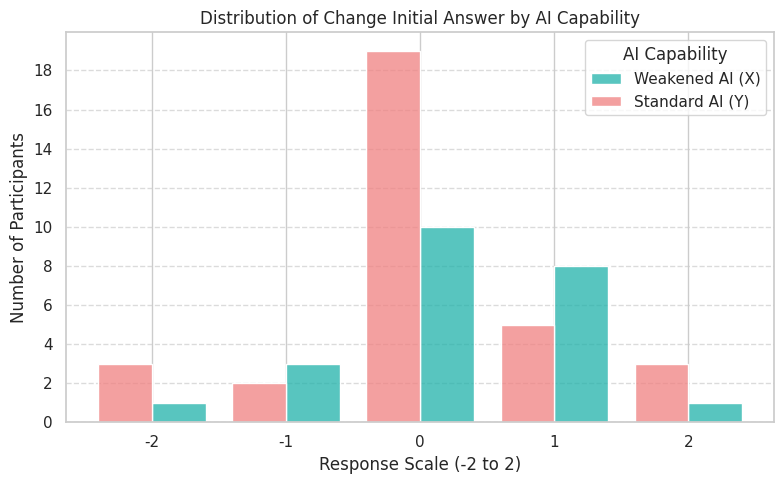

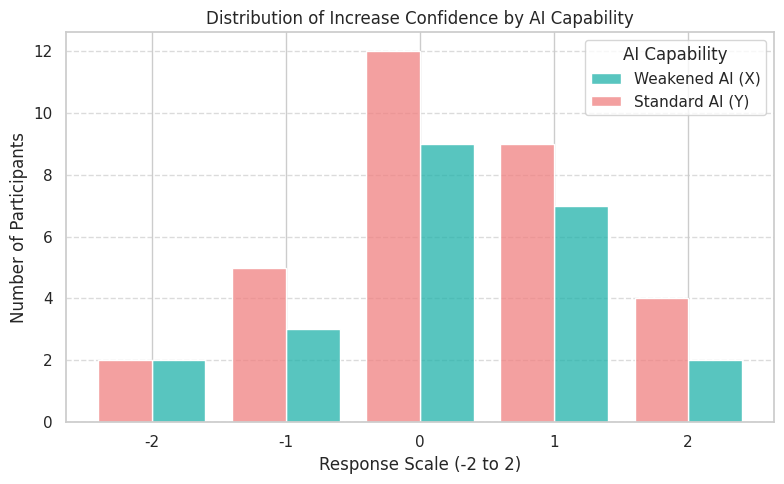

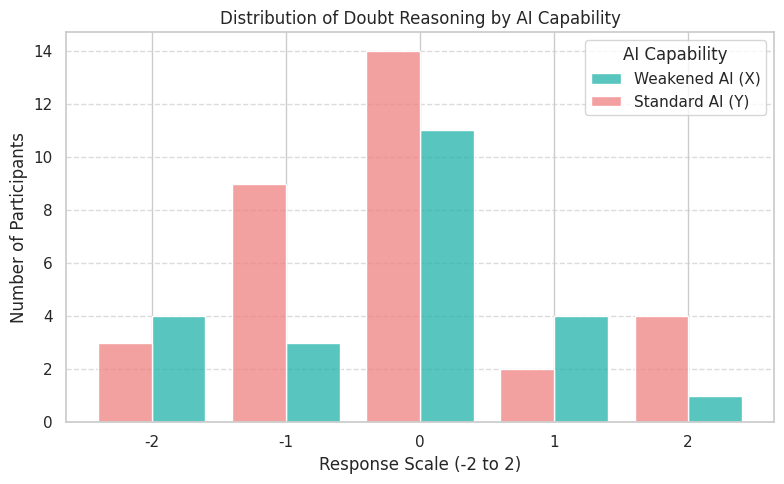

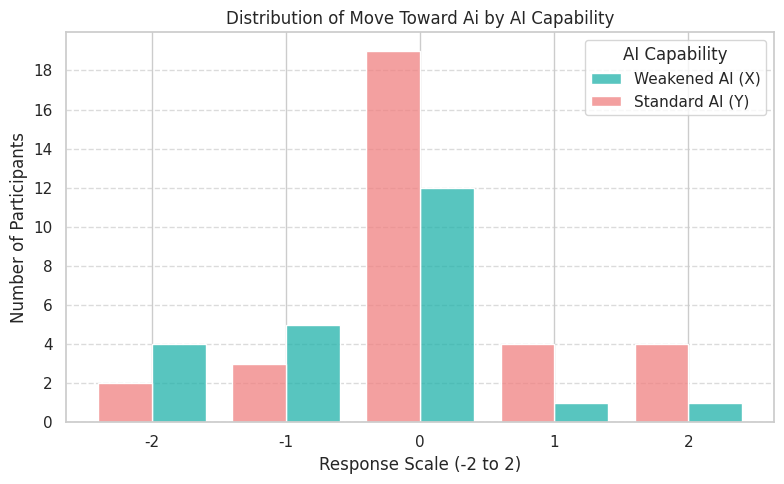

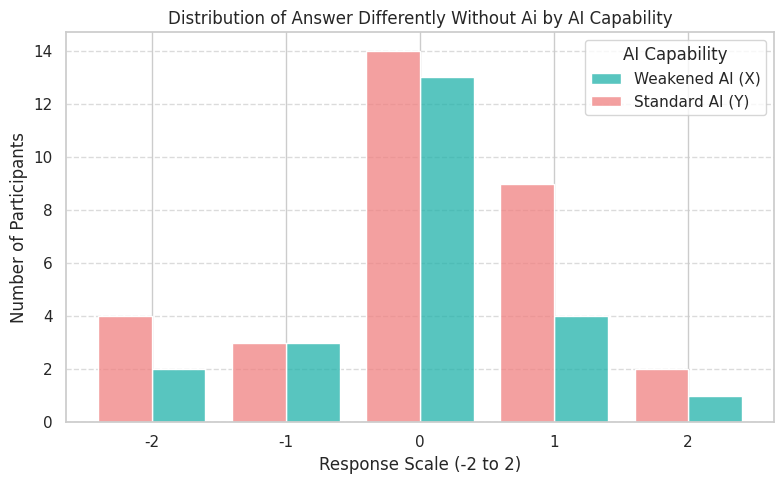

In [ ]:
# Define bins for the Likert scale responses (-2 to 2)
bins = np.arange(-2.5, 2.5 + 1, 1)
x_labels = {-2: '-2', -1: '-1', 0: '0', 1: '1', 2: '2'}

for item in likert_items:
    plt.figure(figsize=(8, 5))
    sns.histplot(
        data=participant_df,
        x=item,
        hue='group_XY',
        multiple='dodge', # Use 'dodge' to show bars side-by-side for comparison
        bins=bins,
        kde=False,
        palette={'X': 'lightcoral', 'Y': 'lightseagreen'},
        discrete=True,
        shrink=0.8
    )
    plt.title(f'Distribution of {item.replace('_', ' ').title()} by AI Capability')
    plt.xlabel('Response Scale (-2 to 2)')
    plt.ylabel('Number of Participants')
    custom_ticks = [-2, -1, 0, 1, 2]
    custom_labels = [x_labels.get(tick) for tick in custom_ticks]
    plt.xticks(custom_ticks, custom_labels)
    plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(2))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='AI Capability', labels=['Weakened AI (X)', 'Standard AI (Y)'])
    plt.tight_layout()
    plt.show()


#### Statistical test

In [ ]:
print("Statistical Tests for Post-Quiz Perception: AI Capability (Mann-Whitney U and Fligner-Killeen):\n")

for item in likert_items:
    print(f"--- Analyzing: {item.replace('_', ' ').title()} ---")

    group_X_data = participant_df_X[item].dropna() # Drop NaN values for the test
    group_Y_data = participant_df_Y[item].dropna()

    if len(group_X_data) == 0 or len(group_Y_data) == 0:
        print(f"  Skipping {item}: Not enough data in one or both groups.\n")
        continue

    # Mann-Whitney U test
    mw_statistic, mw_p_value = mannwhitneyu(group_X_data, group_Y_data, alternative='two-sided')
    print(f"  Mann-Whitney U Test for {item.replace('_', ' ').title()}:")
    print(f"    Statistic = {mw_statistic:.3f}, P-value = {mw_p_value:.3f}")
    if mw_p_value < alpha:
        print(f"    -> Reject H0: Significant difference in median {item.replace('_', ' ')} between groups (p < {alpha})")
    else:
        print(f"    -> Fail to reject H0: No significant difference in median {item.replace('_', ' ')} between groups (p >= {alpha})")

    # Fligner-Killeen test for homogeneity of variances
    fk_statistic, fk_p_value = stats.fligner(group_X_data, group_Y_data)
    print(f"  Fligner-Killeen Test for {item.replace('_', ' ').title()} (Homogeneity of Variances):")
    print(f"    Statistic = {fk_statistic:.3f}, P-value = {fk_p_value:.3f}")
    if fk_p_value < alpha:
        print(f"    -> Reject H0: Variances are significantly different between groups (p < {alpha})")
    else:
        print(f"    -> Fail to reject H0: Variances are not significantly different between groups (p >= {alpha})")
    print("\n")

print('\nInterpretation notes:')
print("Mann-Whitney U tests for differences in central tendency (medians) between two independent groups. Fligner-Killeen tests for homogeneity of variances. When interpreting these results, especially for multiple tests, it's important to consider the increased risk of Type I errors (false positives).")

Statistical Tests for Post-Quiz Perception: AI Capability (Mann-Whitney U and Fligner-Killeen):

--- Analyzing: Change Initial Answer ---
  Mann-Whitney U Test for Change Initial Answer:
    Statistic = 335.000, P-value = 0.545
    -> Fail to reject H0: No significant difference in median change initial answer between groups (p >= 0.05)
  Fligner-Killeen Test for Change Initial Answer (Homogeneity of Variances):
    Statistic = 0.052, P-value = 0.819
    -> Fail to reject H0: Variances are not significantly different between groups (p >= 0.05)


--- Analyzing: Increase Confidence ---
  Mann-Whitney U Test for Increase Confidence:
    Statistic = 379.000, P-value = 0.851
    -> Fail to reject H0: No significant difference in median increase confidence between groups (p >= 0.05)
  Fligner-Killeen Test for Increase Confidence (Homogeneity of Variances):
    Statistic = 0.023, P-value = 0.880
    -> Fail to reject H0: Variances are not significantly different between groups (p >= 0.05)


-

**Effect of Reliability Framing on Post-Quiz Likert Responses**

#### Research premise
This hypothesis investigates whether a participant's reliability framing of AI (Group A) or lack thereof (Group B) influences their post-quiz perceptions as measured by various Likert-scale items. We aim to determine if participants in the aware group (Group A) report different perceptions (e.g., changes in initial answer, confidence, doubt, movement toward AI, or answering differently without AI) compared to those in the unaware group (Group B).

#### Variable and level of analysis
- Dependent variables: `change_initial_answer`, `increase_confidence`, `doubt_reasoning`, `move_toward_ai`, `answer_differently_without_ai` (each on a Likert scale from -2 to 2)
- Unit of analysis: `participant` (each row in `participant_df` represents a unique participant)
- Groups compared: Group A (aware participants) vs. Group B (unaware participants)

#### Null and alternative hypotheses
For each Likert item: {`change_initial_answer`, `increase_confidence`, `doubt_reasoning`, `move_toward_ai`, `answer_differently_without_ai`}

- $H_0$: There is no difference in the median perception score for $item$ between participants in Group A (aware) and Group B (unaware). (Median $item_A$ = Median $item_B$)
- $H_a$: There is a difference in the median perception score for $item$ between participants in Group A (aware) and Group B (unaware). (Median $item_A \ne$ Median $item_B$)

#### Choice of test
Given the ordinal nature of Likert scale data and the lack of assumption of normality for such data, non-parametric tests are appropriate. For each of the five Likert items, a **Mann-Whitney U test (two-sided)** will be conducted to compare the median scores between Group A and Group B. Additionally, the **Fligner-Killeen test** will be used to assess the homogeneity of variances (or scale parameters) for each item between the two groups.

#### Prepare data

In [ ]:
participant_df_A = participant_df[participant_df['group_AB'] == 'A']
participant_df_B = participant_df[participant_df['group_AB'] == 'B']

print(f"Number of participants in Group A (aware): {len(participant_df_A)}")
print(f"Number of participants in Group B (unaware): {len(participant_df_B)}")


Number of participants in Group A (aware): 23
Number of participants in Group B (unaware): 32


#### Descriptive statistics

In [ ]:
print("\nDescriptive Statistics for Likert Items (Group A vs. Group B):\n")
for item in likert_items:
    print(f"--- {item.replace('_', ' ').title()} ---")
    print("Group A (aware):")
    print(participant_df_A[item].describe())
    print("Median Group A:", participant_df_A[item].median())
    print("\nGroup B (unaware):")
    print(participant_df_B[item].describe())
    print("Median Group B:", participant_df_B[item].median())
    print("\n")


Descriptive Statistics for Likert Items (Group A vs. Group B):

--- Change Initial Answer ---
Group A (aware):
count    23.000000
mean      0.217391
std       0.518435
min      -1.000000
25%       0.000000
50%       0.000000
75%       0.500000
max       1.000000
Name: change_initial_answer, dtype: float64
Median Group A: 0.0

Group B (unaware):
count    32.000000
mean      0.093750
std       1.173893
min      -2.000000
25%      -0.250000
50%       0.000000
75%       1.000000
max       2.000000
Name: change_initial_answer, dtype: float64
Median Group B: 0.0


--- Increase Confidence ---
Group A (aware):
count    23.000000
mean      0.304348
std       0.875670
min      -1.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       2.000000
Name: increase_confidence, dtype: float64
Median Group A: 0.0

Group B (unaware):
count    32.000000
mean      0.156250
std       1.194325
min      -2.000000
25%      -0.250000
50%       0.000000
75%       1.000000
max       2.000000
Nam

#### Data visualization

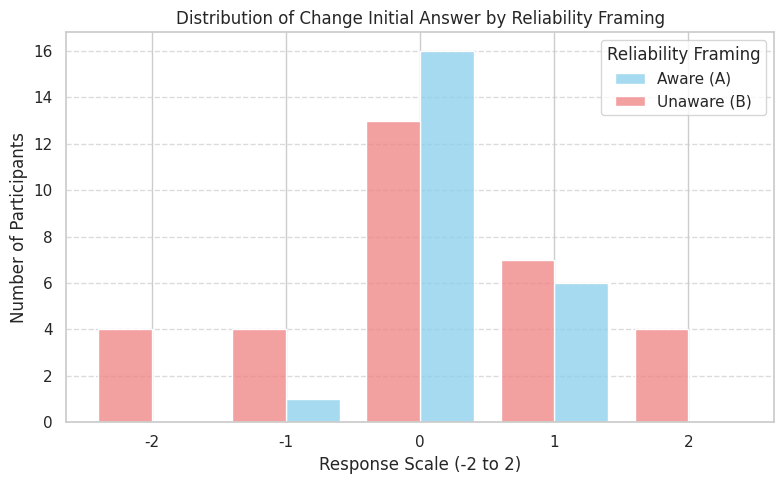

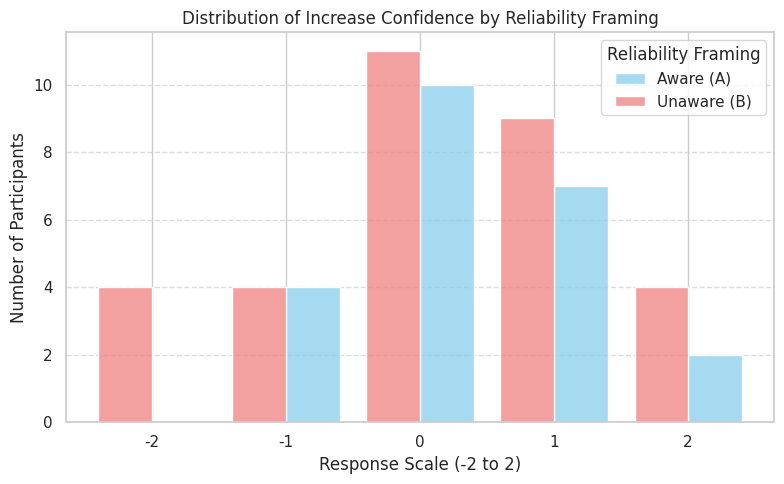

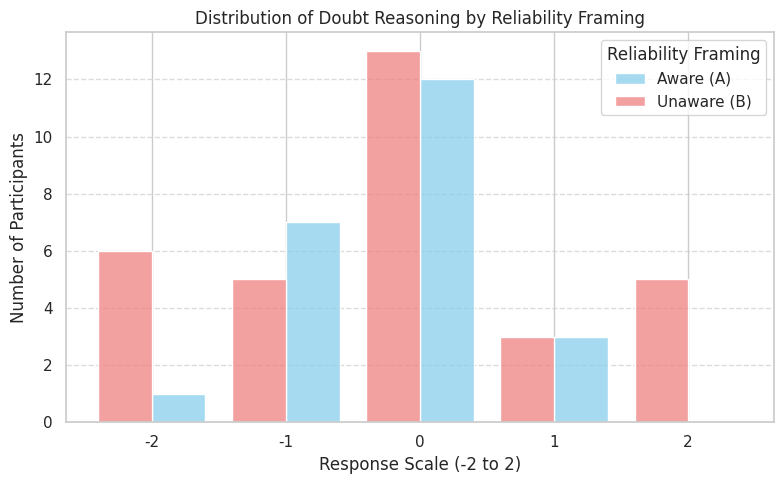

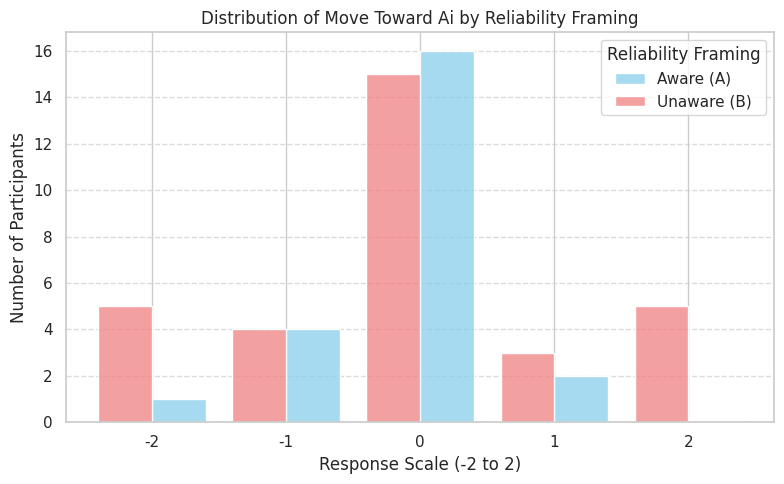

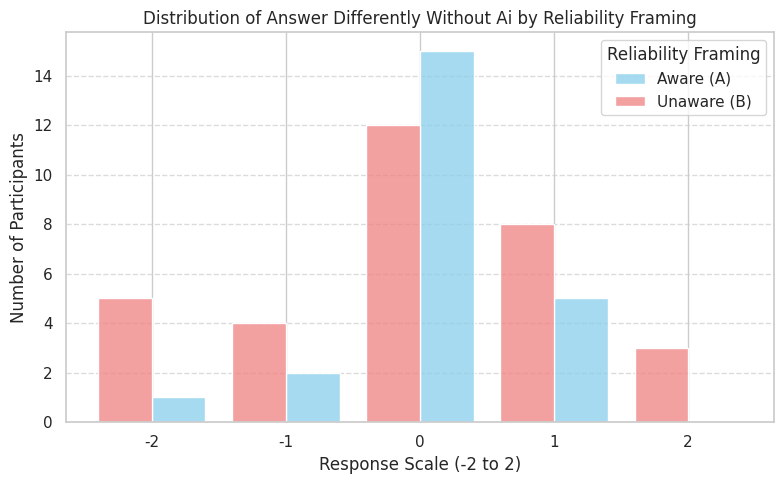

In [ ]:
# Define bins for the Likert scale responses (-2 to 2)
bins = np.arange(-2.5, 2.5 + 1, 1)
x_labels = {-2: '-2', -1: '-1', 0: '0', 1: '1', 2: '2'}

for item in likert_items:
    plt.figure(figsize=(8, 5))
    sns.histplot(
        data=participant_df,
        x=item,
        hue='group_AB',
        multiple='dodge', # Use 'dodge' to show bars side-by-side for comparison
        bins=bins,
        kde=False,
        palette={'A': 'skyblue', 'B': 'lightcoral'},
        discrete=True,
        shrink=0.8
    )
    plt.title(f'Distribution of {item.replace('_', ' ').title()} by Reliability Framing')
    plt.xlabel('Response Scale (-2 to 2)')
    plt.ylabel('Number of Participants')
    custom_ticks = [-2, -1, 0, 1, 2]
    custom_labels = [x_labels.get(tick) for tick in custom_ticks]
    plt.xticks(custom_ticks, custom_labels)
    plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(2))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Reliability Framing', labels=['Aware (A)', 'Unaware (B)'])
    plt.tight_layout()
    plt.show()

#### Statistical test

In [ ]:
print("Statistical Tests for Post-Quiz Perception: Reliability Framing (Mann-Whitney U and Fligner-Killeen):\n")

for item in likert_items:
    print(f"--- Analyzing: {item.replace('_', ' ').title()} ---")

    group_A_data = participant_df_A[item].dropna()
    group_B_data = participant_df_B[item].dropna()

    if len(group_A_data) == 0 or len(group_B_data) == 0:
        print(f"  Skipping {item}: Not enough data in one or both groups.\n")
        continue

    # Mann-Whitney U test
    mw_statistic, mw_p_value = mannwhitneyu(group_A_data, group_B_data, alternative='two-sided')
    print(f"  Mann-Whitney U Test for {item.replace('_', ' ').title()}:")
    print(f"    Statistic = {mw_statistic:.3f}, P-value = {mw_p_value:.3f}")
    if mw_p_value < alpha:
        print(f"    -> Reject H0: Significant difference in median {item.replace('_', ' ')} between groups (p < {alpha})")
    else:
        print(f"    -> Fail to reject H0: No significant difference in median {item.replace('_', ' ')} between groups (p >= {alpha})")

    # Fligner-Killeen test for homogeneity of variances
    fk_statistic, fk_p_value = stats.fligner(group_A_data, group_B_data)
    print(f"  Fligner-Killeen Test for {item.replace('_', ' ').title()} (Homogeneity of Variances):")
    print(f"    Statistic = {fk_statistic:.3f}, P-value = {fk_p_value:.3f}")
    if fk_p_value < alpha:
        print(f"    -> Reject H0: Variances are significantly different between groups (p < {alpha})")
    else:
        print(f"    -> Fail to reject H0: Variances are not significantly different between groups (p >= {alpha})")
    print("\n")

print('\nInterpretation notes:')
print("Mann-Whitney U tests for differences in central tendency (medians) between two independent groups. Fligner-Killeen tests for homogeneity of variances. When interpreting these results, especially for multiple tests, it's important to consider the increased risk of Type I errors (false positives).")

Statistical Tests for Post-Quiz Perception: Reliability Framing (Mann-Whitney U and Fligner-Killeen):

--- Analyzing: Change Initial Answer ---
  Mann-Whitney U Test for Change Initial Answer:
    Statistic = 385.000, P-value = 0.759
    -> Fail to reject H0: No significant difference in median change initial answer between groups (p >= 0.05)
  Fligner-Killeen Test for Change Initial Answer (Homogeneity of Variances):
    Statistic = 7.370, P-value = 0.007
    -> Reject H0: Variances are significantly different between groups (p < 0.05)


--- Analyzing: Increase Confidence ---
  Mann-Whitney U Test for Increase Confidence:
    Statistic = 383.500, P-value = 0.789
    -> Fail to reject H0: No significant difference in median increase confidence between groups (p >= 0.05)
  Fligner-Killeen Test for Increase Confidence (Homogeneity of Variances):
    Statistic = 1.847, P-value = 0.174
    -> Fail to reject H0: Variances are not significantly different between groups (p >= 0.05)


--- Anal

**Differences in Post-Quiz Likert Responses Across the Four Experimental Groups**

#### Research premise
This hypothesis investigates the combined effect of AI capability (weakened/standard) and reliability framing (aware/unaware) on participant perceptions, as measured by five Likert-scale items, across the four original experimental groups (G1, G2, G3, G4). We aim to determine if different combinations of AI capability and reliability framing lead to significant differences in perceptions (e.g., changes in initial answer, confidence, doubt, movement toward AI, or answering differently without AI).

#### Variable and level of analysis
- Dependent variables: `change_initial_answer`, `increase_confidence`, `doubt_reasoning`, `move_toward_ai`, `answer_differently_without_ai` (each on a Likert scale from -2 to 2)
- Unit of analysis: `participant` (each row in `participant_df` represents a unique participant)
- Groups compared: G1 (aware + weakened), G2 (aware + standard), G3 (unaware + weakened), G4 (unaware + standard)

#### Null and alternative hypotheses
For each Likert item (`change_initial_answer`, `increase_confidence`, `doubt_reasoning`, `move_toward_ai`, `answer_differently_without_ai`)

- $H_0$: There is no difference in the median perception score for $item$ among the four experimental groups (G1, G2, G3, G4).
- $H_a$: At least one group's median perception score for $item$ is different from another group's median perception score.

#### Choice of test
Given the ordinal nature of Likert scale data and the comparison of more than two independent groups, a non-parametric test is appropriate. For each of the five Likert items, a **Kruskal-Wallis H test** will be conducted to determine if there are statistically significant differences among the medians of the four groups (G1, G2, G3, G4). Additionally, a **Fligner-Killeen test** will be used to assess the homogeneity of variances (or scale parameters) for each item between all groups.

If the Kruskal-Wallis test yields a significant result ($p < \alpha$), a **Dunn's post-hoc test with Bonferroni correction** will be performed to identify which specific pairs of groups have significantly different medians, while controlling for the family-wise error rate.

#### Prepare data for H5

In [ ]:
group_G1_perceptions = participant_df[participant_df['group_label'] == 'G1']
group_G2_perceptions = participant_df[participant_df['group_label'] == 'G2']
group_G3_perceptions = participant_df[participant_df['group_label'] == 'G3']
group_G4_perceptions = participant_df[participant_df['group_label'] == 'G4']

print(f"Number of participants in G1 (aware + weakened): {len(group_G1_perceptions)}")
print(f"Number of participants in G2 (aware + standard): {len(group_G2_perceptions)}")
print(f"Number of participants in G3 (unaware + weakened): {len(group_G3_perceptions)}")
print(f"Number of participants in G4 (unaware + standard): {len(group_G4_perceptions)}")

# The 'likert_items' list is already defined in the global context.

Number of participants in G1 (aware + weakened): 14
Number of participants in G2 (aware + standard): 9
Number of participants in G3 (unaware + weakened): 18
Number of participants in G4 (unaware + standard): 14


#### Descriptive statistics

In [ ]:
print("Descriptive Statistics for Likert Items (G1, G2, G3, G4 groups):\n")

for item in likert_items:
    print(f"--- {item.replace('_', ' ').title()} ---")
    print("Group G1 (aware + weakened):")
    print(group_G1_perceptions[item].describe())
    print("Median Group G1:", group_G1_perceptions[item].median())

    print("\nGroup G2 (aware + standard):")
    print(group_G2_perceptions[item].describe())
    print("Median Group G2:", group_G2_perceptions[item].median())

    print("\nGroup G3 (unaware + weakened):")
    print(group_G3_perceptions[item].describe())
    print("Median Group G3:", group_G3_perceptions[item].median())

    print("\nGroup G4 (unaware + standard):")
    print(group_G4_perceptions[item].describe())
    print("Median Group G4:", group_G4_perceptions[item].median())
    print("\n")

Descriptive Statistics for Likert Items (G1, G2, G3, G4 groups):

--- Change Initial Answer ---
Group G1 (aware + weakened):
count    14.000000
mean      0.000000
std       0.392232
min      -1.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       1.000000
Name: change_initial_answer, dtype: float64
Median Group G1: 0.0

Group G2 (aware + standard):
count    9.000000
mean     0.555556
std      0.527046
min      0.000000
25%      0.000000
50%      1.000000
75%      1.000000
max      1.000000
Name: change_initial_answer, dtype: float64
Median Group G2: 1.0

Group G3 (unaware + weakened):
count    18.000000
mean      0.166667
std       1.294786
min      -2.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       2.000000
Name: change_initial_answer, dtype: float64
Median Group G3: 0.0

Group G4 (unaware + standard):
count    14.000000
mean      0.000000
std       1.037749
min      -2.000000
25%      -0.750000
50%       0.000000
75%       0.750000
max  

#### Data visualization

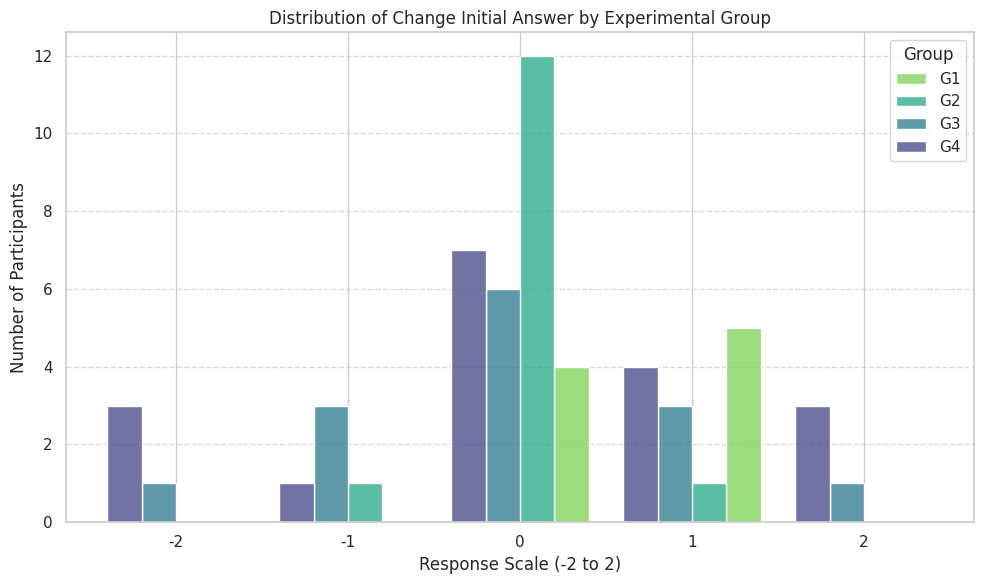

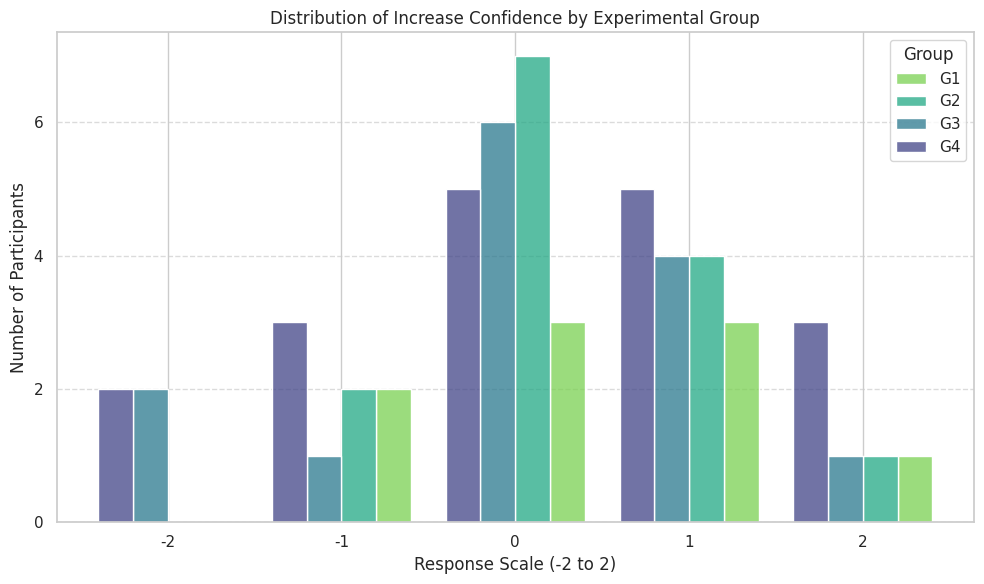

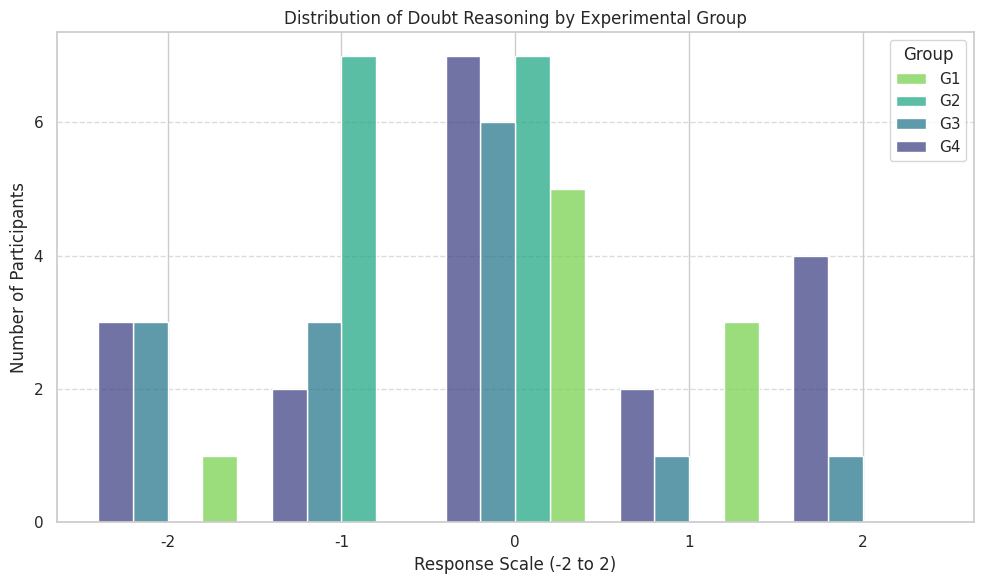

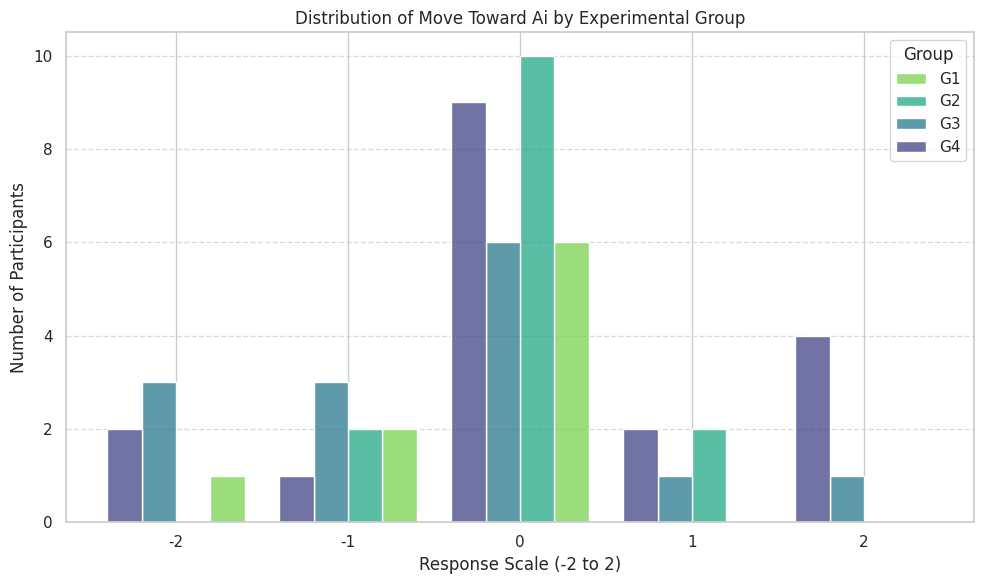

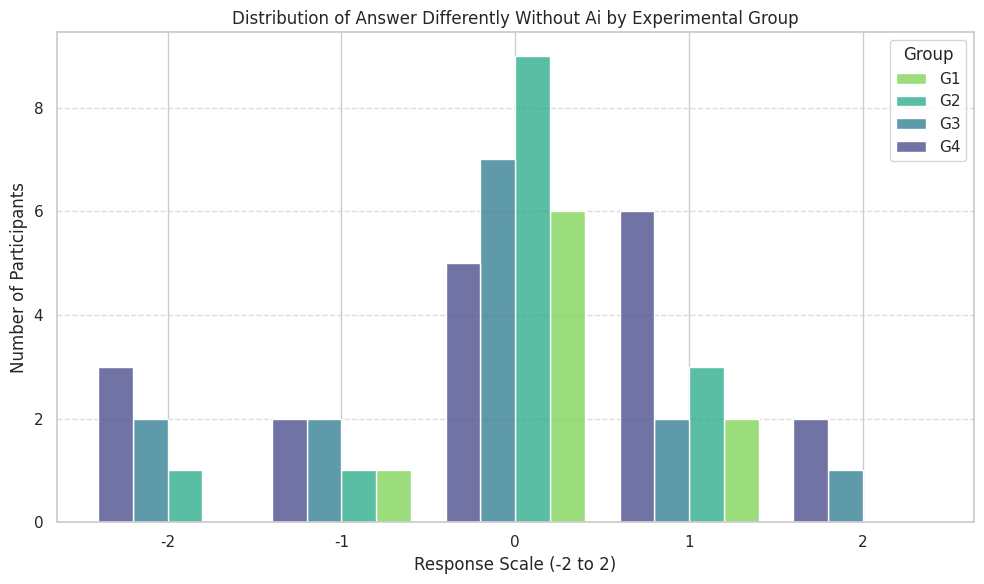

In [ ]:
# Define bins for the Likert scale responses (-2 to 2)
bins = np.arange(-2.5, 2.5 + 1, 1)
x_labels = {-2: '-2', -1: '-1', 0: '0', 1: '1', 2: '2'}

for item in likert_items:
    plt.figure(figsize=(10, 6))
    sns.histplot(
        data=participant_df,
        x=item,
        hue='group_label',
        multiple='dodge',
        bins=bins,
        kde=False,
        palette='viridis',
        discrete=True,
        shrink=0.8
    )
    plt.title(f'Distribution of {item.replace('_', ' ').title()} by Experimental Group')
    plt.xlabel('Response Scale (-2 to 2)')
    plt.ylabel('Number of Participants')
    custom_ticks = [-2, -1, 0, 1, 2]
    custom_labels = [x_labels.get(tick) for tick in custom_ticks]
    plt.xticks(custom_ticks, custom_labels)
    plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(2))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Group', labels=['G1', 'G2', 'G3', 'G4'])
    plt.tight_layout()
    plt.show()

#### Statistical test

In [ ]:
print("Statistical Tests (Kruskal-Wallis H test and Fligner-Killeen test):\n")

for item in likert_items:
    print(f"--- Analyzing: {item.replace('_', ' ').title()} ---")

    # Extract data for each group for the current Likert item
    data_G1 = group_G1_perceptions[item].dropna()
    data_G2 = group_G2_perceptions[item].dropna()
    data_G3 = group_G3_perceptions[item].dropna()
    data_G4 = group_G4_perceptions[item].dropna()

    # Check if any group has insufficient data
    if any(len(d) == 0 for d in [data_G1, data_G2, data_G3, data_G4]):
        print(f"  Skipping {item}: Not enough data in one or more groups.\n")
        continue

    # Kruskal-Wallis H test
    kruskal_stat, kruskal_p = stats.kruskal(data_G1, data_G2, data_G3, data_G4)
    print(f"  Kruskal-Wallis H Test for {item.replace('_', ' ').title()}:")
    print(f"    Statistic = {kruskal_stat:.3f}, P-value = {kruskal_p:.3f}")

    if kruskal_p < alpha: # Use the original alpha for Kruskal-Wallis
        print(f"    -> Reject H0: Significant difference in median {item.replace('_', ' ')} among groups (p < {alpha})")
        print("    Performing Dunn's post-hoc test with Bonferroni correction:")
        # Prepare data for post-hoc test in a single DataFrame
        data_for_posthoc = pd.DataFrame({
            'value': pd.concat([data_G1, data_G2, data_G3, data_G4]),
            'group': ['G1']*len(data_G1) + ['G2']*len(data_G2) + \
                     ['G3']*len(data_G3) + ['G4']*len(data_G4)
        })
        dunn_results = posthoc_dunn(data_for_posthoc, val_col='value', group_col='group', p_adjust='bonferroni')
        print(dunn_results)
    else:
        print(f"    -> Fail to reject H0: No significant difference in median {item.replace('_', ' ')} among groups (p >= {alpha})")

    # Fligner-Killeen test for homogeneity of variances
    fk_statistic, fk_p_value = stats.fligner(data_G1, data_G2, data_G3, data_G4)
    print(f"  Fligner-Killeen Test for {item.replace('_', ' ').title()} (Homogeneity of Variances):")
    print(f"    Statistic = {fk_statistic:.3f}, P-value = {fk_p_value:.3f}")
    if fk_p_value < alpha: # Using uncorrected alpha for Fligner-Killeen as it's not a primary hypothesis test
        print(f"    -> Reject H0: Variances are significantly different between groups (p < {alpha})")
    else:
        print(f"    -> Fail to reject H0: Variances are not significantly different between groups (p >= {alpha})")
    print("\n")

print('\nInterpretation notes:')
print("Kruskal-Wallis H test determines if population medians are equal across multiple groups. If significant, Dunn's post-hoc test (with Bonferroni correction) identifies which pairs of groups differ significantly. Fligner-Killeen tests for homogeneity of variances. Note that for Fligner-Killeen, we generally use the original alpha as it's often considered a secondary diagnostic test.")

Statistical Tests (Kruskal-Wallis H test and Fligner-Killeen test):

--- Analyzing: Change Initial Answer ---
  Kruskal-Wallis H Test for Change Initial Answer:
    Statistic = 3.877, P-value = 0.275
    -> Fail to reject H0: No significant difference in median change initial answer among groups (p >= 0.05)
  Fligner-Killeen Test for Change Initial Answer (Homogeneity of Variances):
    Statistic = 10.147, P-value = 0.017
    -> Reject H0: Variances are significantly different between groups (p < 0.05)


--- Analyzing: Increase Confidence ---
  Kruskal-Wallis H Test for Increase Confidence:
    Statistic = 0.221, P-value = 0.974
    -> Fail to reject H0: No significant difference in median increase confidence among groups (p >= 0.05)
  Fligner-Killeen Test for Increase Confidence (Homogeneity of Variances):
    Statistic = 2.835, P-value = 0.418
    -> Fail to reject H0: Variances are not significantly different between groups (p >= 0.05)


--- Analyzing: Doubt Reasoning ---
  Kruskal-

## 7. Notebook Summary

In [ ]:
from IPython.display import display, Markdown

# ---------- Effect size functions ----------

def rank_biserial_abs(u_statistic, n1, n2):
    """
    Rank-biserial correlation for Mann-Whitney U.
    Absolute value is used for effect size magnitude.
    """
    r = 1 - (2 * u_statistic) / (n1 * n2)
    return abs(r)

def epsilon_squared_kw(H, n):
    """
    Epsilon-squared for Kruskal-Wallis.
    Formula: ε² = H / (n - 1)
    """
    return H / (n - 1)

def test_result(p_value, alpha=0.05):
    return "Reject H0" if p_value < alpha else "Fail to reject H0"


# ---------- Summary builder ----------

summary_rows = []

def add_mannwhitney_row(section, comparison, groups, outcome, x, y, alternative="two-sided"):
    x = x.dropna()
    y = y.dropna()

    u_stat, p_value = mannwhitneyu(x, y, alternative=alternative)
    effect_size = rank_biserial_abs(u_stat, len(x), len(y))

    summary_rows.append({
        "Section": section,
        "Comparison": comparison,
        "Groups": groups,
        "Outcome": outcome,
        "Test": "Mann-Whitney U",
        "Statistic": u_stat,
        "p-value": p_value,
        "Effect size": effect_size,
        "Result": test_result(p_value, alpha)
    })


def add_kruskal_row(section, comparison, groups, outcome, data_groups):
    clean_groups = [g.dropna() for g in data_groups]

    H_stat, p_value = stats.kruskal(*clean_groups)
    n_total = sum(len(g) for g in clean_groups)
    effect_size = epsilon_squared_kw(H_stat, n_total)

    summary_rows.append({
        "Section": section,
        "Comparison": comparison,
        "Groups": groups,
        "Outcome": outcome,
        "Test": "Kruskal-Wallis H",
        "Statistic": H_stat,
        "p-value": p_value,
        "Effect size": effect_size,
        "Result": test_result(p_value, alpha)
    })


# ---------- Groups ----------

participant_df_X = participant_df[participant_df["group_XY"] == "X"]
participant_df_Y = participant_df[participant_df["group_XY"] == "Y"]

participant_df_A = participant_df[participant_df["group_AB"] == "A"]
participant_df_B = participant_df[participant_df["group_AB"] == "B"]

participant_df_G1 = participant_df[participant_df["group_label"] == "G1"]
participant_df_G2 = participant_df[participant_df["group_label"] == "G2"]
participant_df_G3 = participant_df[participant_df["group_label"] == "G3"]
participant_df_G4 = participant_df[participant_df["group_label"] == "G4"]


# ---------- H1: Quiz Performance ----------

add_mannwhitney_row(
    section="H1: Quiz Performance",
    comparison="Effect of AI Capability on Quiz Grade",
    groups="Group X vs. Group Y",
    outcome="grade",
    x=participant_df_X["grade"],
    y=participant_df_Y["grade"],
    alternative="less"
)

add_mannwhitney_row(
    section="H1: Quiz Performance",
    comparison="Effect of Reliability Framing on Quiz Grade",
    groups="Group A vs. Group B",
    outcome="grade",
    x=participant_df_A["grade"],
    y=participant_df_B["grade"],
    alternative="two-sided"
)

add_kruskal_row(
    section="H1: Quiz Performance",
    comparison="Differences in Quiz Grade Across the Four Experimental Groups",
    groups="G1, G2, G3, G4",
    outcome="grade",
    data_groups=[
        participant_df_G1["grade"],
        participant_df_G2["grade"],
        participant_df_G3["grade"],
        participant_df_G4["grade"]
    ]
)


# ---------- H2: AI Usage Frequency ----------

add_mannwhitney_row(
    section="H2: AI Usage Frequency",
    comparison="Effect of AI Capability on AI Usage Frequency",
    groups="Group X vs. Group Y",
    outcome="n_used_ia",
    x=participant_df_X["n_used_ia"],
    y=participant_df_Y["n_used_ia"],
    alternative="less"
)

add_mannwhitney_row(
    section="H2: AI Usage Frequency",
    comparison="Effect of Reliability Framing on AI Usage Frequency",
    groups="Group A vs. Group B",
    outcome="n_used_ia",
    x=participant_df_A["n_used_ia"],
    y=participant_df_B["n_used_ia"],
    alternative="two-sided"
)

add_kruskal_row(
    section="H2: AI Usage Frequency",
    comparison="Differences in AI Usage Frequency Across the Four Experimental Groups",
    groups="G1, G2, G3, G4",
    outcome="n_used_ia",
    data_groups=[
        participant_df_G1["n_used_ia"],
        participant_df_G2["n_used_ia"],
        participant_df_G3["n_used_ia"],
        participant_df_G4["n_used_ia"]
    ]
)


# ---------- H3: Post-Quiz Perception ----------

likert_items = [
    "change_initial_answer",
    "increase_confidence",
    "doubt_reasoning",
    "move_toward_ai",
    "answer_differently_without_ai"
]

for item in likert_items:
    add_mannwhitney_row(
        section="H3: Post-Quiz Perception",
        comparison=f"Effect of AI Capability on {item}",
        groups="Group X vs. Group Y",
        outcome=item,
        x=participant_df_X[item],
        y=participant_df_Y[item],
        alternative="two-sided"
    )

for item in likert_items:
    add_mannwhitney_row(
        section="H3: Post-Quiz Perception",
        comparison=f"Effect of Reliability Framing on {item}",
        groups="Group A vs. Group B",
        outcome=item,
        x=participant_df_A[item],
        y=participant_df_B[item],
        alternative="two-sided"
    )

for item in likert_items:
    add_kruskal_row(
        section="H3: Post-Quiz Perception",
        comparison=f"Differences in {item} Across the Four Experimental Groups",
        groups="G1, G2, G3, G4",
        outcome=item,
        data_groups=[
            participant_df_G1[item],
            participant_df_G2[item],
            participant_df_G3[item],
            participant_df_G4[item]
        ]
    )


# ---------- Final summary table ----------

summary_df = pd.DataFrame(summary_rows)

# Rounded version for display
summary_display = summary_df.copy()
summary_display["Statistic"] = summary_display["Statistic"].round(3)
summary_display["p-value"] = summary_display["p-value"].round(3)
summary_display["Effect size"] = summary_display["Effect size"].round(3)

display(summary_display)

# Optional: display as markdown table
#display(Markdown(summary_display.to_markdown(index=False)))

# Optional: export
#summary_df.to_csv("notebook_summary.csv", index=False)
#summary_df.to_excel("notebook_summary.xlsx", index=False)

,Section,Comparison,Groups,Outcome,Test,Statistic,p-value,Effect size,Result
0,H1: Quiz Performance,Effect of AI Capability on Quiz Grade,Group X vs. Group Y,grade,Mann-Whitney U,214.500,0.004,0.417,Reject H0
1,H1: Quiz Performance,Effect of Reliability Framing on Quiz Grade,Group A vs. Group B,grade,Mann-Whitney U,358.000,0.869,0.027,Fail to reject H0
2,H1: Quiz Performance,Differences in Quiz Grade Across the Four Expe...,"G1, G2, G3, G4",grade,Kruskal-Wallis H,7.161,0.067,0.133,Fail to reject H0
3,H2: AI Usage Frequency,Effect of AI Capability on AI Usage Frequency,Group X vs. Group Y,n_used_ia,Mann-Whitney U,253.000,0.021,0.312,Reject H0
4,H2: AI Usage Frequency,Effect of Reliability Framing on AI Usage Freq...,Group A vs. Group B,n_used_ia,Mann-Whitney U,298.500,0.220,0.189,Fail to reject H0
5,H2: AI Usage Frequency,Differences in AI Usage Frequency Across the F...,"G1, G2, G3, G4",n_used_ia,Kruskal-Wallis H,5.584,0.134,0.103,Fail to reject H0
6,H3: Post-Quiz Perception,Effect of AI Capability on change_initial_answer,Group X vs. Group Y,change_initial_answer,Mann-Whitney U,335.000,0.545,0.090,Fail to reject H0
7,H3: Post-Quiz Perception,Effect of AI Capability on increase_confidence,Group X vs. Group Y,increase_confidence,Mann-Whitney U,379.000,0.851,0.030,Fail to reject H0
8,H3: Post-Quiz Perception,Effect of AI Capability on doubt_reasoning,Group X vs. Group Y,doubt_reasoning,Mann-Whitney U,360.500,0.899,0.020,Fail to reject H0
9,H3: Post-Quiz Perception,Effect of AI Capability on move_toward_ai,Group X vs. Group Y,move_toward_ai,Mann-Whitney U,484.500,0.028,0.317,Reject H0
